# 🏦 Finance Sentiment Intelligence — Full Pipeline Notebook

Run every phase from top to bottom. Each section is clearly labelled.

| Phase | What it does |
|---|---|
| 0 | Setup & imports |
| 1 | *(Skipped)* — raw CSV already present |
| 2 | Clean & preprocess text |
| 3 | TF-IDF + numeric feature engineering |
| 4 | Train 3 ML models |
| 5 | Hyperparameter tuning |
| 6 | Model comparison & best model selection |
| 7 | Visualisations & stats report |

> ⚠️ **Run cells top-to-bottom.** Each phase depends on the one above it.

---
## ⚙️ Phase 0 — Setup
Install packages and download NLTK assets. Only needs to run once.

In [1]:
# Install all dependencies
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-r", "requirements.txt", "-q"])
print("✅ Packages installed")

✅ Packages installed


In [2]:
import nltk
for corpus in ["vader_lexicon", "stopwords", "wordnet", "punkt", "punkt_tab", "omw-1.4"]:
    nltk.download(corpus, quiet=True)
print("✅ NLTK assets ready")

✅ NLTK assets ready


In [4]:
# Make sure we're running from the project root so all imports resolve
import os, sys
from pathlib import Path

# If the notebook is inside a sub-folder, walk up until we find requirements.txt
root = Path.cwd()
for _ in range(4):
    if (root / "requirements.txt").exists():
        break
    root = root.parent

os.chdir(root)
if str(root) not in sys.path:
    sys.path.insert(0, str(root))

print(f"✅ Working directory: {root}")

✅ Working directory: C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence


In [5]:
# Silence noisy warnings for a clean notebook experience
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")           # headless — figures will display inline below
import matplotlib.pyplot as plt
import joblib

from IPython.display import display, Image, HTML

# Inline figures
%matplotlib inline
plt.rcParams["figure.dpi"] = 110

print("✅ Core imports done")

✅ Core imports done


---
## 📥 Phase 1 — Raw Data
Your `data/raw/reddit_posts.csv` is already present from the scraper, so we just load and preview it.

In [ ]:
from src.data.data_loader import load_raw_data

df_raw = load_raw_data()

print(f"Shape : {df_raw.shape}")
print(f"Columns: {list(df_raw.columns)}")
display(df_raw.head(10))

In [ ]:
print("Sentiment distribution in raw data:")
display(df_raw["sentiment"].value_counts().to_frame("count"))

print("\nSubreddit distribution:")
display(df_raw["subreddit"].value_counts().to_frame("count"))

---
## 🧹 Phase 2 — Preprocessing
Drop nulls/duplicates → clean text → engineer columns → remove outliers → encode labels.

In [6]:
from src.data.data_loader import load_raw_data, save_processed_data
from src.preprocessing.cleaner import full_clean
from src.preprocessing.wrangler import (
    drop_nulls_and_duplicates,
    add_engineered_columns,
    encode_sentiment,
    remove_outliers_iqr,
    remove_outliers_zscore,
    filter_short_texts,
    print_descriptive_stats,
)
from src.preprocessing.tokenizer import get_token_stats

df = load_raw_data()

print("Step 1 — Drop nulls & duplicates...")
df = drop_nulls_and_duplicates(df)

print("Step 2 — Cleaning text (may take a minute)...")
df["cleaned_text"] = df["text"].apply(full_clean)

print("Step 3 — Engineering columns...")
df = add_engineered_columns(df)

print("Step 4 — Filtering short texts...")
df = filter_short_texts(df, min_words=5)

print("Step 5 — Removing outliers...")
df = remove_outliers_iqr(df, "score")
df = remove_outliers_iqr(df, "num_comments")
df = remove_outliers_zscore(df, "text_length", threshold=3.0)

print("Step 6 — Encoding sentiment labels...")
df = encode_sentiment(df)

print(f"\n✅ Preprocessing complete — {len(df):,} clean rows")

2026-04-21 00:17:06 | INFO | src.data.data_loader | Loaded raw data: 1140 rows, 10 cols
Step 1 — Drop nulls & duplicates...
2026-04-21 00:17:06 | INFO | src.preprocessing.wrangler | Dropped nulls/duplicates: 62 rows removed
Step 2 — Cleaning text (may take a minute)...
Step 3 — Engineering columns...
Step 4 — Filtering short texts...
2026-04-21 00:17:09 | INFO | src.preprocessing.wrangler | Short text filter: removed 310 rows (min_words=5)
Step 5 — Removing outliers...
2026-04-21 00:17:09 | INFO | src.preprocessing.wrangler | IQR [score]: removed 24 outliers (kept 744 rows, bounds=[1.0, 1.0])
2026-04-21 00:17:09 | INFO | src.preprocessing.wrangler | IQR [num_comments]: removed 168 outliers (kept 576 rows, bounds=[0.0, 0.0])
2026-04-21 00:17:09 | INFO | src.preprocessing.wrangler | Z-score [text_length]: removed 10 outliers (threshold=3.0)
Step 6 — Encoding sentiment labels...

✅ Preprocessing complete — 566 clean rows


In [7]:
print_descriptive_stats(df)


📊  DESCRIPTIVE STATISTICS

🔢 Shape          : 566 rows × 19 columns

📌 Sentiment Distribution:
   positive    :   313  (55.3%)
   negative    :   139  (24.6%)
   neutral     :   114  (20.1%)

📌 Subreddit Distribution:
subreddit
wallstreetbets       293
stocks               109
investing             85
IndianStockMarket     79

📌 Numeric Summary:
       score  num_comments  text_length  word_count  engagement
count  566.0         566.0       566.00      566.00       566.0
mean     1.0           0.0       283.95       46.12         1.0
std      0.0           0.0       371.69       56.03         0.0
min      1.0           0.0        32.00        4.00         1.0
25%      1.0           0.0        75.00       13.00         1.0
50%      1.0           0.0       127.00       24.00         1.0
75%      1.0           0.0       302.75       52.00         1.0
max      1.0           0.0      2436.00      381.00         1.0

📌 Missing Values:
title    437
url      438



In [8]:
stats = get_token_stats(df["cleaned_text"].tolist())
print("📌 Token Stats:")
print(f"   Total tokens  : {stats['total_tokens']:,}")
print(f"   Unique tokens : {stats['unique_tokens']:,}")
print(f"   Avg per doc   : {stats['avg_per_doc']}")
print(f"   Top 10 tokens : {stats['top_10_tokens']}")

📌 Token Stats:
   Total tokens  : 13,777
   Unique tokens : 3,605
   Avg per doc   : 24.34
   Top 10 tokens : [('year', 127), ('market', 123), ('stock', 118), ('wsb', 116), ('not', 111), ('total', 82), ('post', 77), ('like', 75), ('removed', 72), ('would', 67)]


In [9]:
# Preview cleaned text vs original
display(df[["text", "cleaned_text", "sentiment", "sentiment_label"]].head(5))

save_processed_data(df)
print("✅ Processed data saved")

,text,cleaned_text,sentiment,sentiment_label
1,"Gold Plunges 1.6%! The $3,300 Make-or-Break Ba...",gold plunge 300 make break battle kick tonight...,negative,0
2,Are we following Argentina's footsteps? Trump ...,following argentina footstep trump following m...,negative,0
3,💹 What’s next for Bursa Malaysia? Market rebou...,next bursa malaysia market rebound amid cautio...,negative,0
6,"Sorry, your [submission](https://www.reddit.co...",sorry submission automatically removed due rul...,positive,2
7,“I’ll just keep DCAing” and “Buy the Dip” 2025...,keep dcaing buy dip 2025 market crash catch ph...,positive,2


2026-04-21 00:17:27 | INFO | src.data.data_loader | ✅ Processed data saved to: C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\processed\processed_posts.csv
✅ Processed data saved


---
## 🔢 Phase 3 — Feature Engineering
TF-IDF matrix + numeric scaling + combined feature matrix.

In [10]:
from sklearn.model_selection import train_test_split
from src.data.data_loader import load_processed_data
from src.features.feature_engineer import (
    build_tfidf_matrix,
    scale_numeric_features,
    combine_features,
    get_top_terms_by_sentiment,
)
from src.utils.config import MODELS_DIR, RANDOM_STATE, TEST_SIZE

df = load_processed_data()
df = df[df["cleaned_text"].str.strip().str.len() > 0].reset_index(drop=True)
print(f"Usable rows: {len(df):,}")

X_text = df["cleaned_text"]
y      = df["sentiment_label"]

(X_text_train, X_text_test,
 y_train,      y_test,
 df_train,     df_test) = train_test_split(
    X_text, y, df,
    test_size    = TEST_SIZE,
    random_state = RANDOM_STATE,
    stratify     = y,
)
print(f"Train: {len(X_text_train):,}  |  Test: {len(X_text_test):,}")

2026-04-21 00:17:45 | INFO | src.data.data_loader | Loaded processed data: 566 rows, 19 cols
Usable rows: 566
Train: 452  |  Test: 114


In [11]:
print("Building TF-IDF matrix...")
X_train_tfidf, X_test_tfidf, vectorizer = build_tfidf_matrix(
    X_text_train.tolist(), X_text_test.tolist()
)

print("Scaling numeric features...")
X_train_num, X_test_num, scaler = scale_numeric_features(df_train, df_test)

print("Combining TF-IDF + numeric...")
X_train_combined = combine_features(X_train_tfidf, X_train_num)
X_test_combined  = combine_features(X_test_tfidf,  X_test_num)

print(f"\n✅ Feature matrix shape — Train: {X_train_combined.shape}  |  Test: {X_test_combined.shape}")

Building TF-IDF matrix...
2026-04-21 00:17:51 | INFO | src.features.feature_engineer | Building TF-IDF (max_features=5000, ngrams=(1, 2))...
2026-04-21 00:17:51 | INFO | src.features.feature_engineer |   TF-IDF matrix shape — train: (452, 1766), test: (114, 1766)
2026-04-21 00:17:51 | INFO | src.features.feature_engineer |   ✅ TF-IDF vectorizer saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\tfidf_vectorizer.pkl
Scaling numeric features...
2026-04-21 00:17:51 | INFO | src.features.feature_engineer | Scaling numeric features: ['score', 'num_comments', 'engagement', 'word_count', 'clean_wc', 'text_length']
2026-04-21 00:17:51 | INFO | src.features.feature_engineer |   ✅ Scaler saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\scaler.pkl
Combining TF-IDF + numeric...
2026-04-21 00:17:51 | INFO | src.features.feature_engineer |   Combined feature matrix shape: (452, 1772)
2026-04-21 00:17:51 | INFO | src.features

In [12]:
top_terms = get_top_terms_by_sentiment(df, vectorizer, n=15)
print("📌 Top TF-IDF Terms by Sentiment:")
for sentiment, terms in top_terms.items():
    print(f"   {sentiment:<10}: {', '.join(terms)}")

2026-04-21 00:17:59 | INFO | src.features.feature_engineer |   Top terms [positive]: ['wsb', 'total', 'year', 'comment', 'removed']...
2026-04-21 00:17:59 | INFO | src.features.feature_engineer |   Top terms [negative]: ['not', 'market', 'people', 'shit', 'like']...
2026-04-21 00:17:59 | INFO | src.features.feature_engineer |   Top terms [neutral]: ['removed', 'market', 'buy', '2032', 'one']...
📌 Top TF-IDF Terms by Sentiment:
   positive  : wsb, total, year, comment, removed, stock, best, first, join, submission, account, seen, gold, not, like
   negative  : not, market, people, shit, like, think, nothing, money, one, next, stock, would, deal, place, buy
   neutral   : removed, market, buy, 2032, one, market research, bought, allied market, globally, cagr, cagr allied, 2032 cagr, allied, globally 2032, market reach


In [13]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(X_train_combined, MODELS_DIR / "X_train.pkl")
joblib.dump(X_test_combined,  MODELS_DIR / "X_test.pkl")
joblib.dump(y_train,          MODELS_DIR / "y_train.pkl")
joblib.dump(y_test,           MODELS_DIR / "y_test.pkl")
print("✅ Feature matrices saved")

✅ Feature matrices saved


---
## 🤖 Phase 4 — Model Training
Train Logistic Regression, Naive Bayes, and Random Forest.

In [14]:
from src.models.train import train_all_models, load_model
from src.models.evaluator import print_model_report, print_comparison_table

X_train = joblib.load(MODELS_DIR / "X_train.pkl")
X_test  = joblib.load(MODELS_DIR / "X_test.pkl")
y_train = joblib.load(MODELS_DIR / "y_train.pkl")
y_test  = joblib.load(MODELS_DIR / "y_test.pkl")

results = train_all_models(X_train, y_train, X_test, y_test)
print("✅ All models trained")


🤖  MODEL TRAINING — Phase 4
2026-04-21 00:18:21 | INFO | src.models.train | Training: logistic_regression...
2026-04-21 00:18:22 | INFO | src.models.train |   ✅ logistic_regression | Accuracy: 0.5526 | Time: 0.04s | Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\logistic_regression.pkl
2026-04-21 00:18:22 | INFO | src.models.train | Training: naive_bayes...
2026-04-21 00:18:22 | INFO | src.models.train |   ✅ naive_bayes | Accuracy: 0.5877 | Time: 0.01s | Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\naive_bayes.pkl
2026-04-21 00:18:22 | INFO | src.models.train | Training: random_forest...
2026-04-21 00:18:22 | INFO | src.models.train |   ✅ random_forest | Accuracy: 0.5526 | Time: 0.22s | Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\random_forest.pkl
✅  All models trained and saved.
✅ All models trained


In [15]:
for name, result in results.items():
    print_model_report(name, y_test, result["y_pred"])


── LOGISTIC REGRESSION ──
              precision    recall  f1-score   support

    negative       0.57      0.14      0.23        28
     neutral       0.25      0.04      0.07        23
    positive       0.56      0.92      0.70        63

    accuracy                           0.55       114
   macro avg       0.46      0.37      0.33       114
weighted avg       0.50      0.55      0.46       114


── NAIVE BAYES ──
              precision    recall  f1-score   support

    negative       0.75      0.11      0.19        28
     neutral       1.00      0.04      0.08        23
    positive       0.58      1.00      0.73        63

    accuracy                           0.59       114
   macro avg       0.78      0.38      0.33       114
weighted avg       0.71      0.59      0.47       114


── RANDOM FOREST ──
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00        28
     neutral       0.33      0.17      0.23        23
    posi

In [16]:
comparison_df = print_comparison_table(results)
display(comparison_df.style.highlight_max(axis=0, color="#c8f7c5"))


📊  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score Training Time
Model                                                                   
Logistic Regression    0.5526     0.5020  0.5526    0.4573         0.04s
Naive Bayes            0.5877     0.7054  0.5877    0.4677         0.01s
Random Forest          0.5526     0.3869  0.5526    0.4413         0.22s

🏆  Best model by F1-Score: Naive Bayes


,Accuracy,Precision,Recall,F1-Score,Training Time
Model,,,,,
Logistic Regression,0.552600,0.502000,0.552600,0.457300,0.04s
Naive Bayes,0.587700,0.705400,0.587700,0.467700,0.01s
Random Forest,0.552600,0.386900,0.552600,0.441300,0.22s


In [17]:
best_model_name = comparison_df["F1-Score"].idxmax()
best_model_key  = best_model_name.lower().replace(" ", "_")
best_model      = results[best_model_key]["model"]
joblib.dump(best_model, MODELS_DIR / "best_model.pkl")
joblib.dump(results,    MODELS_DIR / "training_results.pkl")
print(f"🏆 Best model: {best_model_name} — saved")

🏆 Best model: Naive Bayes — saved


In [18]:
# Quick sanity check on 3 test samples
model     = load_model("logistic_regression")
sample    = X_test[:3]
preds     = model.predict(sample)
label_map = {0: "negative", 1: "neutral", 2: "positive"}
print("── Sanity Check ──")
for i, p in enumerate(preds):
    actual    = label_map[y_test.iloc[i]]
    predicted = label_map[p]
    match     = "✅" if actual == predicted else "❌"
    print(f"  Sample {i+1}: actual={actual:<10} predicted={predicted:<10} {match}")

2026-04-21 00:18:51 | INFO | src.models.train | Loaded model: logistic_regression ← C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\logistic_regression.pkl
── Sanity Check ──
  Sample 1: actual=positive   predicted=positive   ✅
  Sample 2: actual=positive   predicted=positive   ✅
  Sample 3: actual=positive   predicted=negative   ❌


---
## 🎯 Phase 5 — Hyperparameter Tuning
GridSearchCV for LR & NB, RandomizedSearchCV for Random Forest.

> ⚠️ This is the **slowest phase** (~10–20 min for RF). Feel free to grab a coffee ☕

In [19]:
from src.models.tuner import (
    tune_logistic_regression,
    tune_naive_bayes,
    tune_random_forest,
    evaluate_tuned_model,
    print_tuning_improvement,
)

before_results = joblib.load(MODELS_DIR / "training_results.pkl")

print("Tuning Logistic Regression...")
lr_tuned, lr_search = tune_logistic_regression(X_train, y_train)

print("\nTuning Naive Bayes...")
nb_tuned, nb_search = tune_naive_bayes(X_train, y_train)

print("\nTuning Random Forest (this takes the longest)...")
rf_tuned, rf_search = tune_random_forest(X_train, y_train)

print("\n✅ All models tuned")

Tuning Logistic Regression...
2026-04-21 00:19:04 | INFO | src.models.tuner | Tuning Logistic Regression with GridSearchCV...
Fitting 5 folds for each of 20 candidates, totalling 100 fits
2026-04-21 00:19:15 | INFO | src.models.tuner |   Best params : {'C': 100.0, 'max_iter': 500, 'solver': 'lbfgs'}
2026-04-21 00:19:15 | INFO | src.models.tuner |   Best CV F1  : 0.5749
2026-04-21 00:19:15 | INFO | src.models.tuner |   Time taken  : 10.6s
2026-04-21 00:19:15 | INFO | src.models.tuner |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\models\tuned_logistic_regression.pkl

Tuning Naive Bayes...
2026-04-21 00:19:15 | INFO | src.models.tuner | Tuning Naive Bayes with GridSearchCV...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
2026-04-21 00:19:15 | INFO | src.models.tuner |   Best params : {'alpha': 0.1}
2026-04-21 00:19:15 | INFO | src.models.tuner |   Best CV F1  : 0.5714
2026-04-21 00:19:15 | INFO | src.models.tuner |   Time taken  : 0.1

In [20]:
after_results = {
    "logistic_regression": evaluate_tuned_model(lr_tuned, "logistic_regression", X_test, y_test),
    "naive_bayes":         evaluate_tuned_model(nb_tuned, "naive_bayes",         X_test, y_test),
    "random_forest":       evaluate_tuned_model(rf_tuned, "random_forest",        X_test, y_test),
}

print_tuning_improvement(before_results, after_results)

2026-04-21 00:19:35 | INFO | src.models.tuner |   Tuned logistic_regression → Accuracy: 0.5614 | F1: 0.5610
2026-04-21 00:19:35 | INFO | src.models.tuner |   Tuned naive_bayes → Accuracy: 0.5702 | F1: 0.5470
2026-04-21 00:19:35 | INFO | src.models.tuner |   Tuned random_forest → Accuracy: 0.5439 | F1: 0.4938

📈  TUNING IMPROVEMENT — Before vs After
Model                      Before F1   After F1    Delta
----------------------------------------------------------------------
Logistic Regression           0.4573     0.5610 ⬆ 0.1038
Naive Bayes                   0.4677     0.5470 ⬆ 0.0793
Random Forest                 0.4413     0.4938 ⬆ 0.0525


In [21]:
print("\n📋 Best Hyperparameters:")
print(f"  Logistic Regression : {lr_search.best_params_}")
print(f"  Naive Bayes         : {nb_search.best_params_}")
print(f"  Random Forest       : {rf_search.best_params_}")

joblib.dump(after_results, MODELS_DIR / "tuned_results.pkl")
joblib.dump({"logistic_regression": lr_search,
             "naive_bayes": nb_search,
             "random_forest": rf_search}, MODELS_DIR / "cv_search_objects.pkl")
print("\n✅ Tuned results saved")


📋 Best Hyperparameters:
  Logistic Regression : {'C': 100.0, 'max_iter': 500, 'solver': 'lbfgs'}
  Naive Bayes         : {'alpha': 0.1}
  Random Forest       : {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None}

✅ Tuned results saved


---
## 📊 Phase 6 — Model Comparison
Full evaluation, confusion matrices, ROC curves, and final model selection.

In [22]:
from src.models.evaluator import (
    print_model_report,
    print_comparison_table,
    build_tuned_comparison_table,
    plot_confusion_matrix,
    plot_all_confusion_matrices,
    plot_roc_curves,
    plot_metrics_comparison,
    plot_tuning_improvement,
    select_best_model,
)

before_results = joblib.load(MODELS_DIR / "training_results.pkl")
after_results  = joblib.load(MODELS_DIR / "tuned_results.pkl")

for name, result in after_results.items():
    print_model_report(name, y_test, result["y_pred"])


── LOGISTIC REGRESSION ──
              precision    recall  f1-score   support

    negative       0.41      0.50      0.45        28
     neutral       0.44      0.35      0.39        23
    positive       0.68      0.67      0.67        63

    accuracy                           0.56       114
   macro avg       0.51      0.50      0.50       114
weighted avg       0.57      0.56      0.56       114


── NAIVE BAYES ──
              precision    recall  f1-score   support

    negative       0.46      0.57      0.51        28
     neutral       0.57      0.17      0.27        23
    positive       0.62      0.71      0.67        63

    accuracy                           0.57       114
   macro avg       0.55      0.49      0.48       114
weighted avg       0.57      0.57      0.55       114


── RANDOM FOREST ──
              precision    recall  f1-score   support

    negative       0.43      0.11      0.17        28
     neutral       0.38      0.35      0.36        23
    posi

In [23]:
comparison_df = print_comparison_table(after_results)
display(comparison_df.style.highlight_max(axis=0, color="#c8f7c5"))


📊  MODEL COMPARISON TABLE
                     Accuracy  Precision  Recall  F1-Score Training Time
Model                                                                   
Logistic Regression    0.5614     0.5652  0.5614    0.5610            0s
Naive Bayes            0.5702     0.5730  0.5702    0.5470            0s
Random Forest          0.5439     0.5098  0.5439    0.4938            0s

🏆  Best model by F1-Score: Logistic Regression


,Accuracy,Precision,Recall,F1-Score,Training Time
Model,,,,,
Logistic Regression,0.561400,0.565200,0.561400,0.561000,0s
Naive Bayes,0.570200,0.573000,0.570200,0.547000,0s
Random Forest,0.543900,0.509800,0.543900,0.493800,0s


In [25]:
tuning_df = build_tuned_comparison_table(before_results, after_results)
print("\n📈 Tuning Impact:")
tuning_df.style.map(
    lambda v: "color: green" if isinstance(v, float) and v > 0 else
              "color: red"   if isinstance(v, float) and v < 0 else "",
    subset=["Improvement"]
)


📈 Tuning Impact:


,Before Accuracy,After Accuracy,Before F1,After F1,Improvement
Model,,,,,
Logistic Regression,0.552600,0.561400,0.457300,0.561000,0.103800
Naive Bayes,0.587700,0.570200,0.467700,0.547000,0.079300
Random Forest,0.552600,0.543900,0.441300,0.493800,0.052500


2026-04-21 00:21:07 | INFO | src.models.evaluator |   Saved confusion matrix → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\confusion_matrix_logistic_regression.png


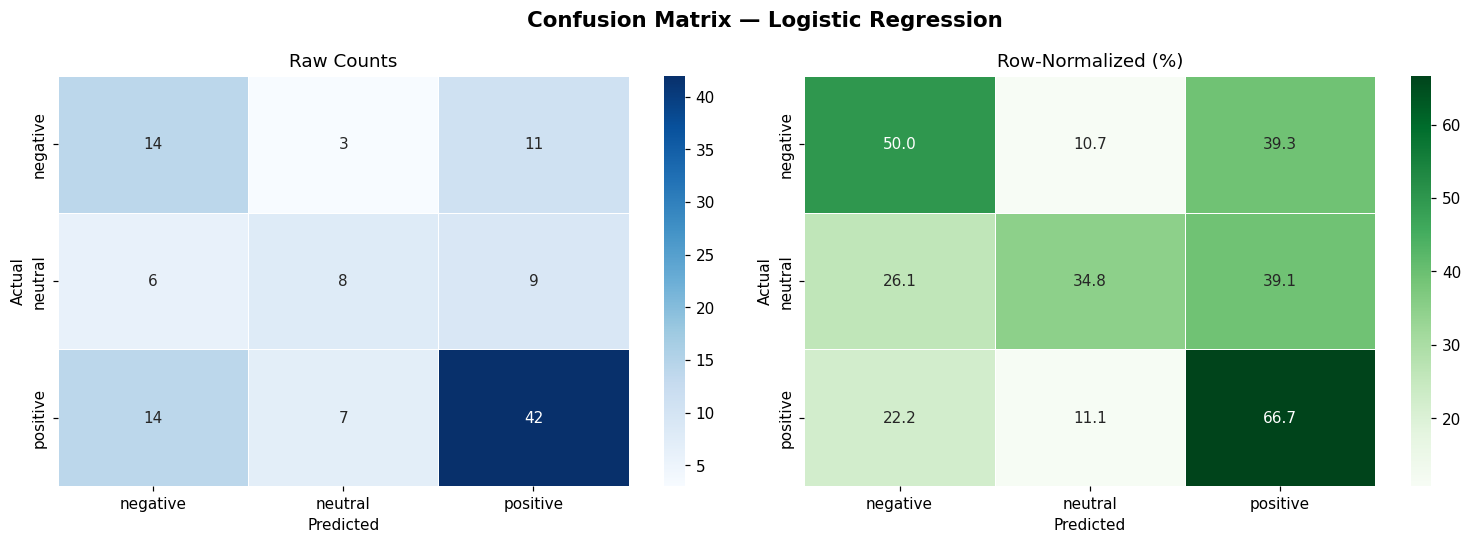

2026-04-21 00:21:07 | INFO | src.models.evaluator |   Saved confusion matrix → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\confusion_matrix_naive_bayes.png


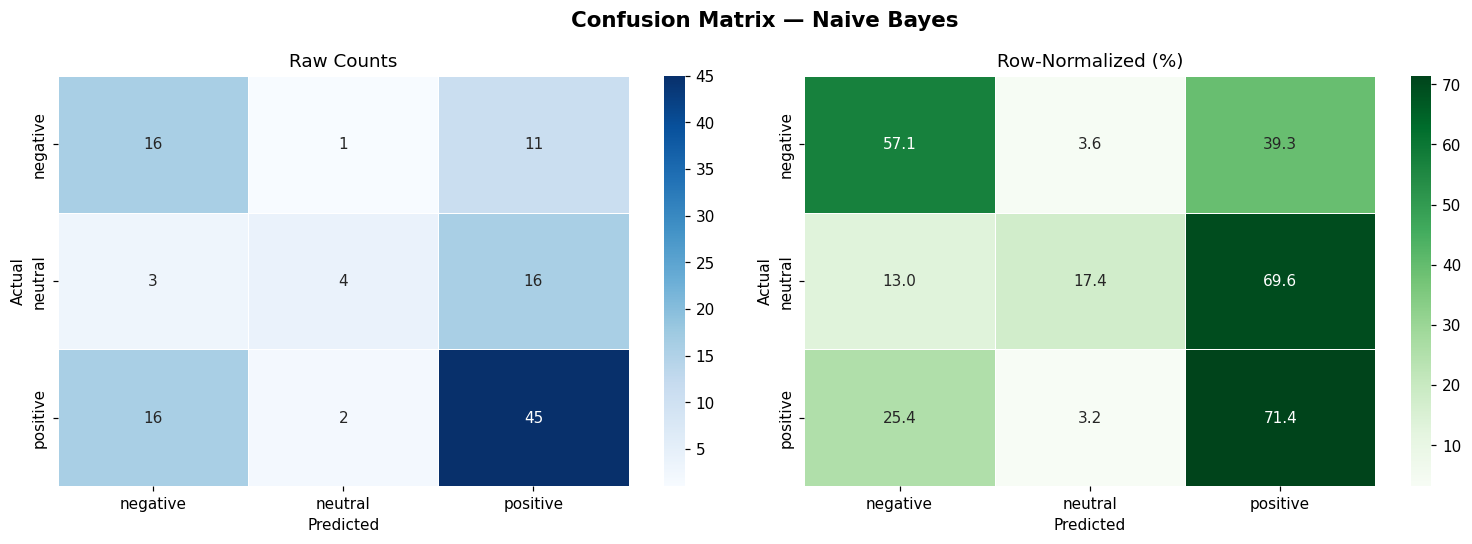

2026-04-21 00:21:08 | INFO | src.models.evaluator |   Saved confusion matrix → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\confusion_matrix_random_forest.png


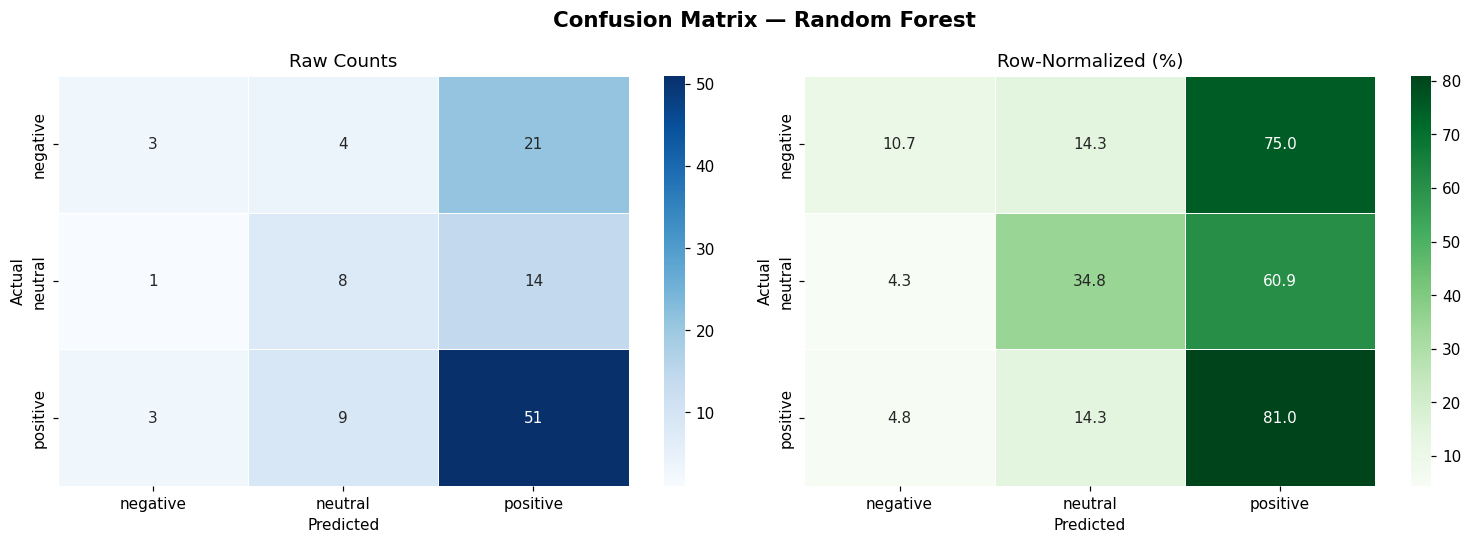

2026-04-21 00:21:09 | INFO | src.models.evaluator |   Saved all confusion matrices → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\confusion_matrices_all.png


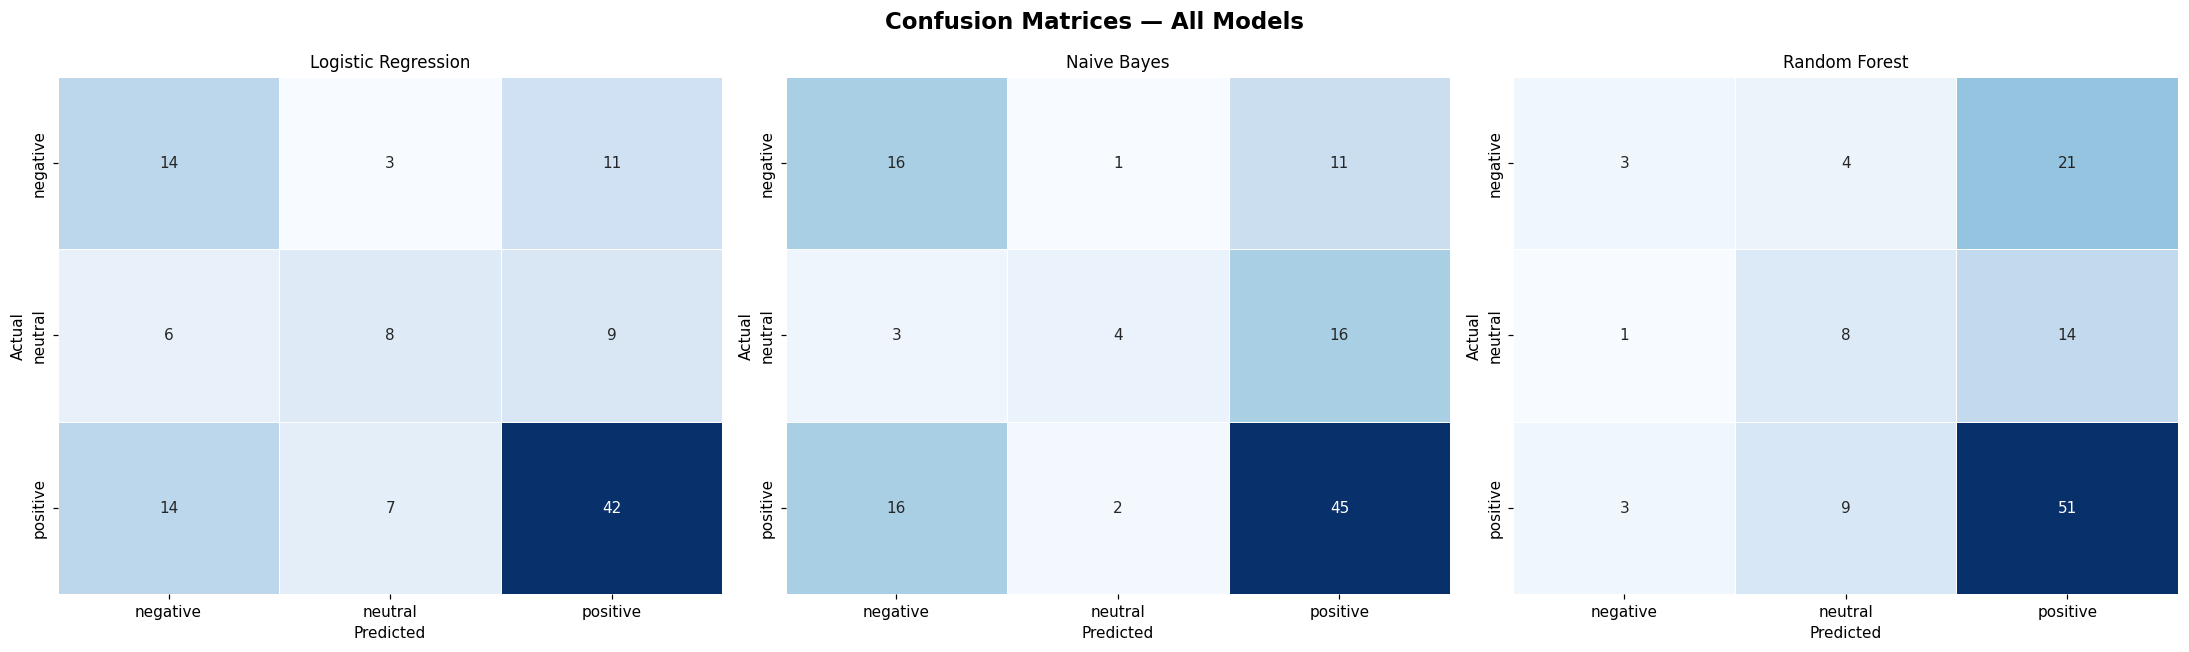

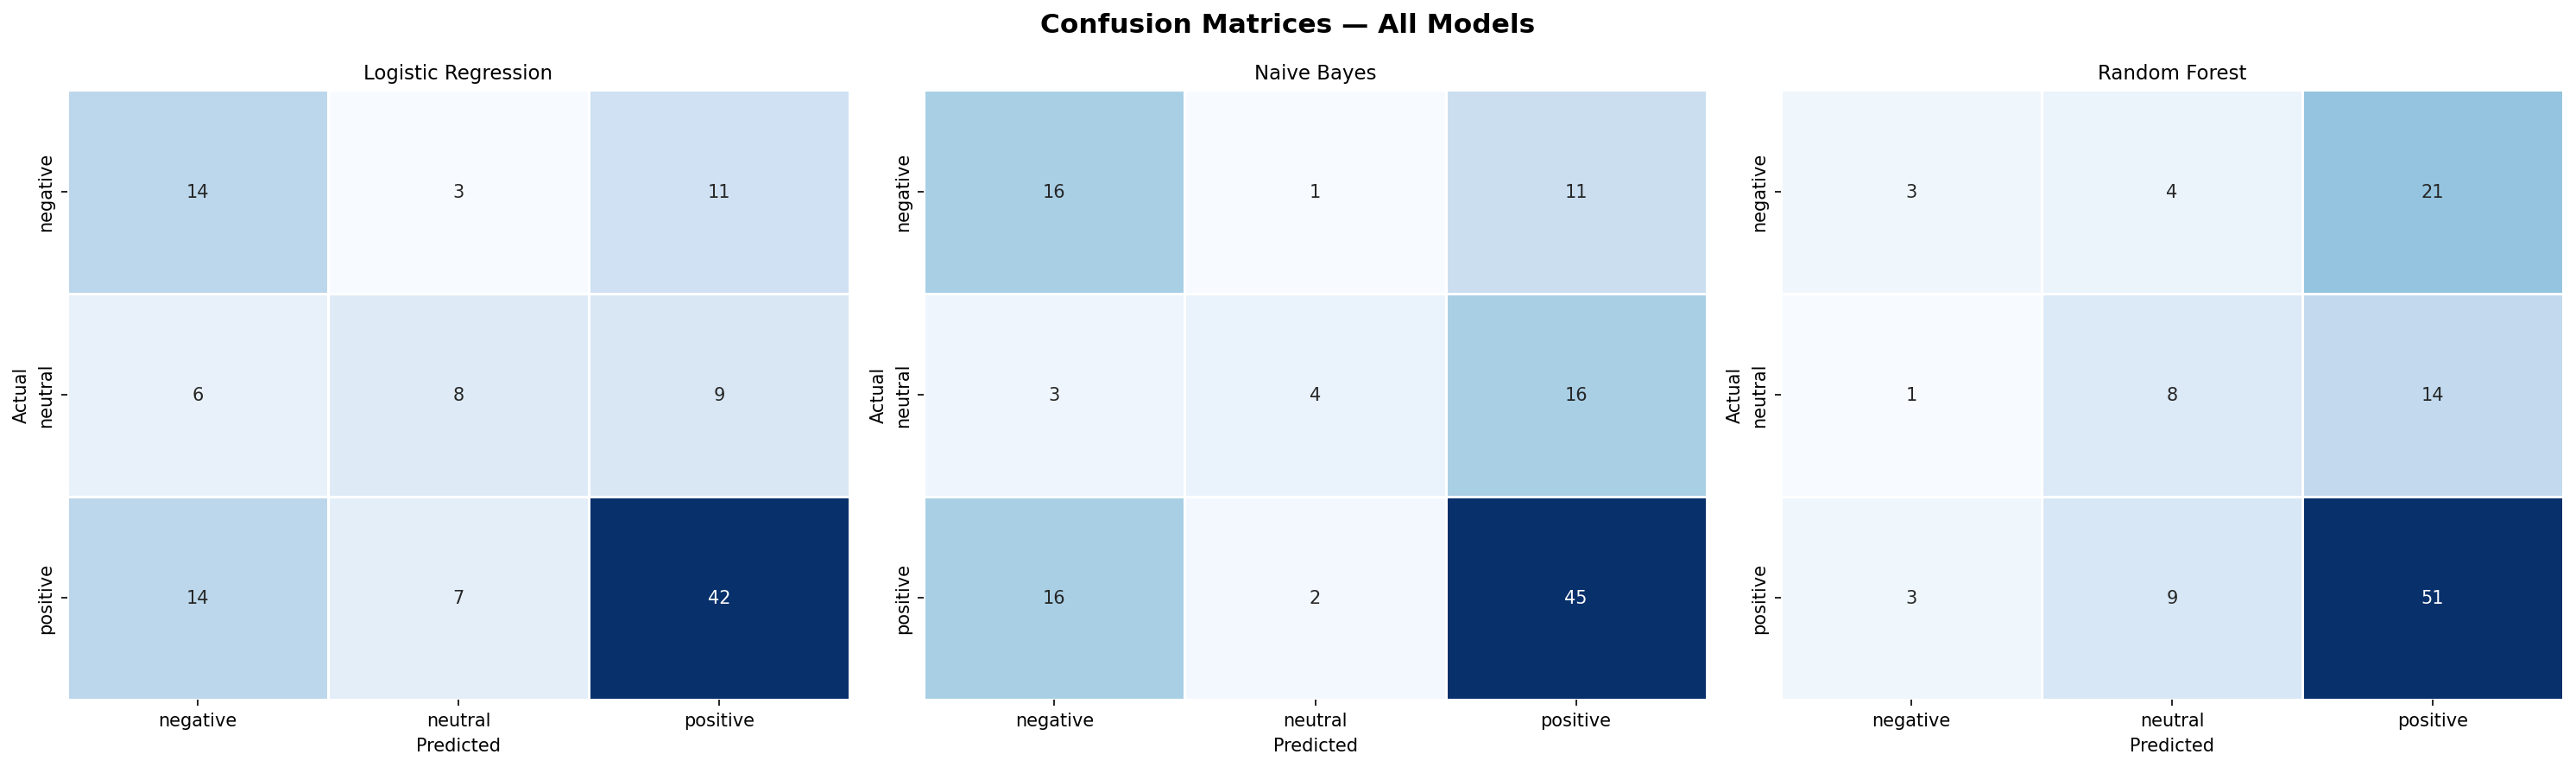

In [26]:
# Confusion matrices — saved to data/plots/ and shown inline
from src.utils.config import MODELS_DIR
PLOTS_DIR = MODELS_DIR.parent.parent / "data" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

for name, result in after_results.items():
    plot_confusion_matrix(y_test, result["y_pred"], name, save=True)

plot_all_confusion_matrices(after_results, y_test)
Image(str(PLOTS_DIR / "confusion_matrices_all.png"))

2026-04-21 00:21:29 | INFO | src.models.evaluator |   Saved metrics comparison → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\metrics_comparison.png


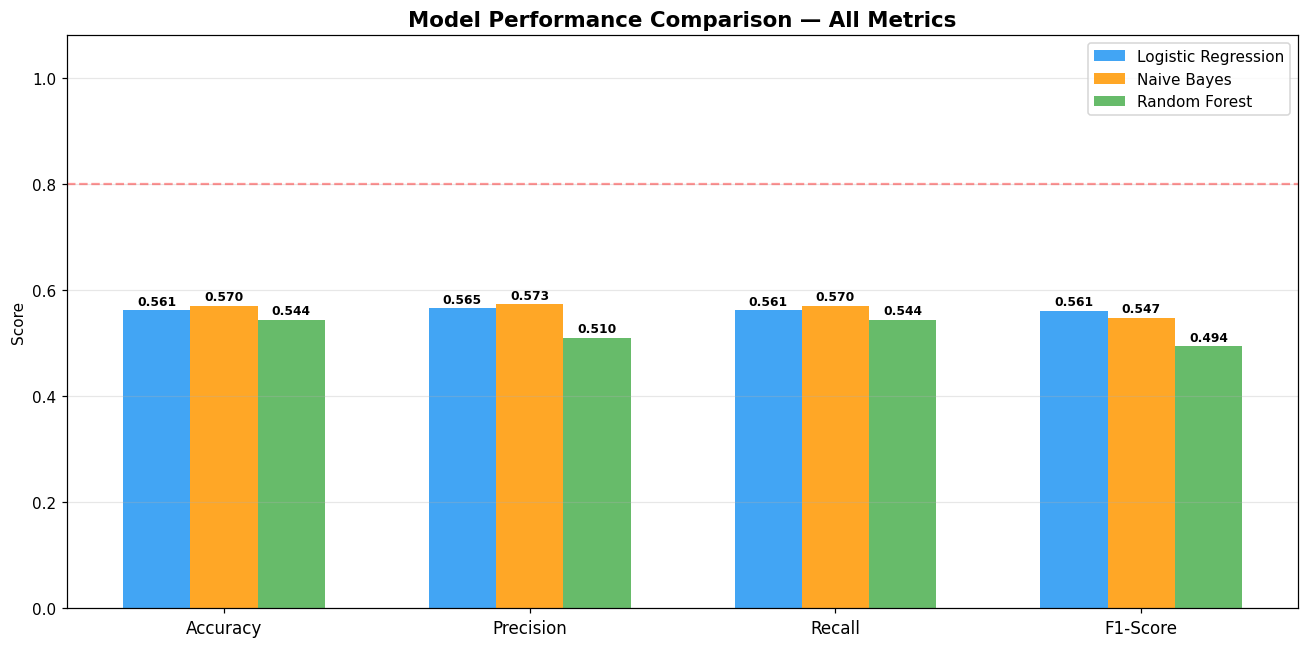

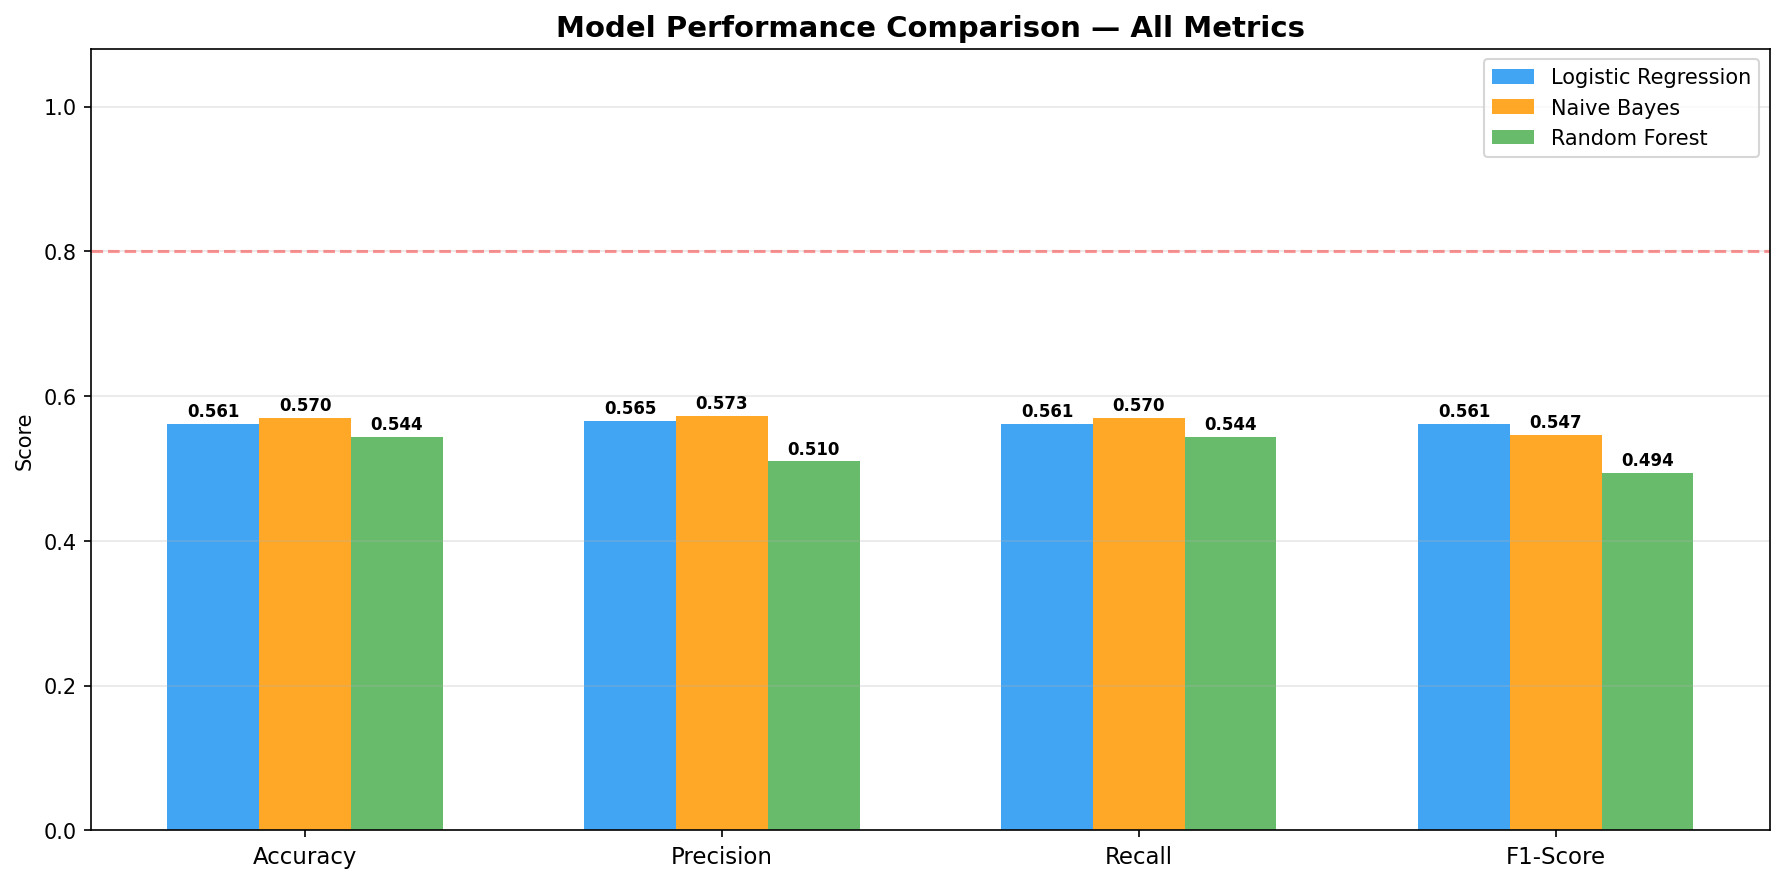

In [27]:
plot_metrics_comparison(after_results)
Image(str(PLOTS_DIR / "metrics_comparison.png"))

2026-04-21 00:21:35 | INFO | src.models.evaluator |   Saved tuning improvement chart → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\tuning_improvement.png


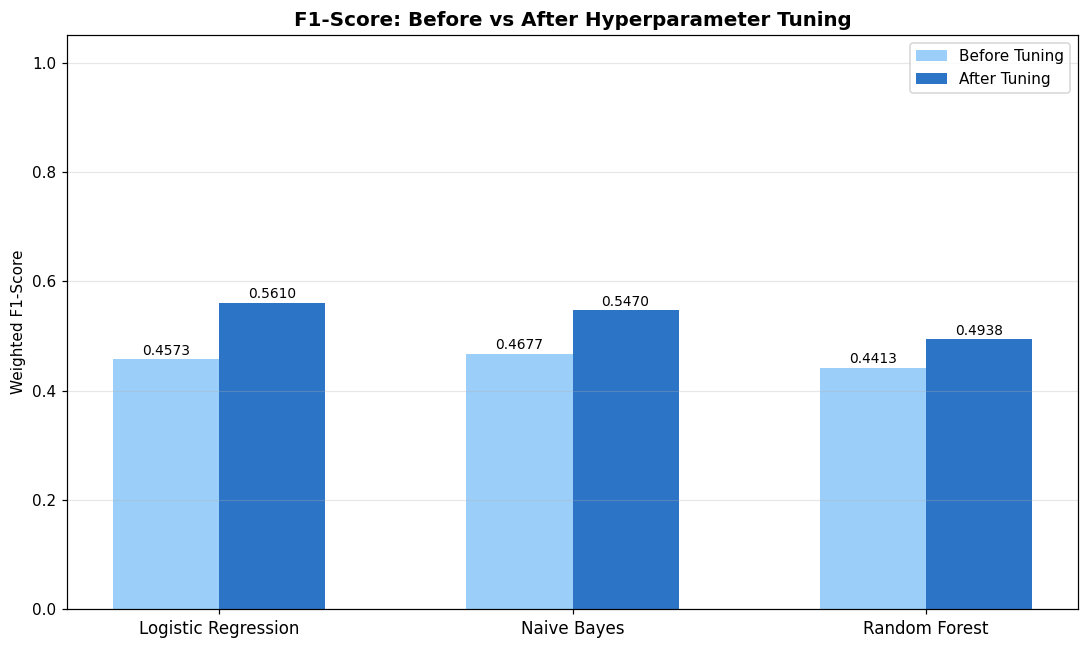

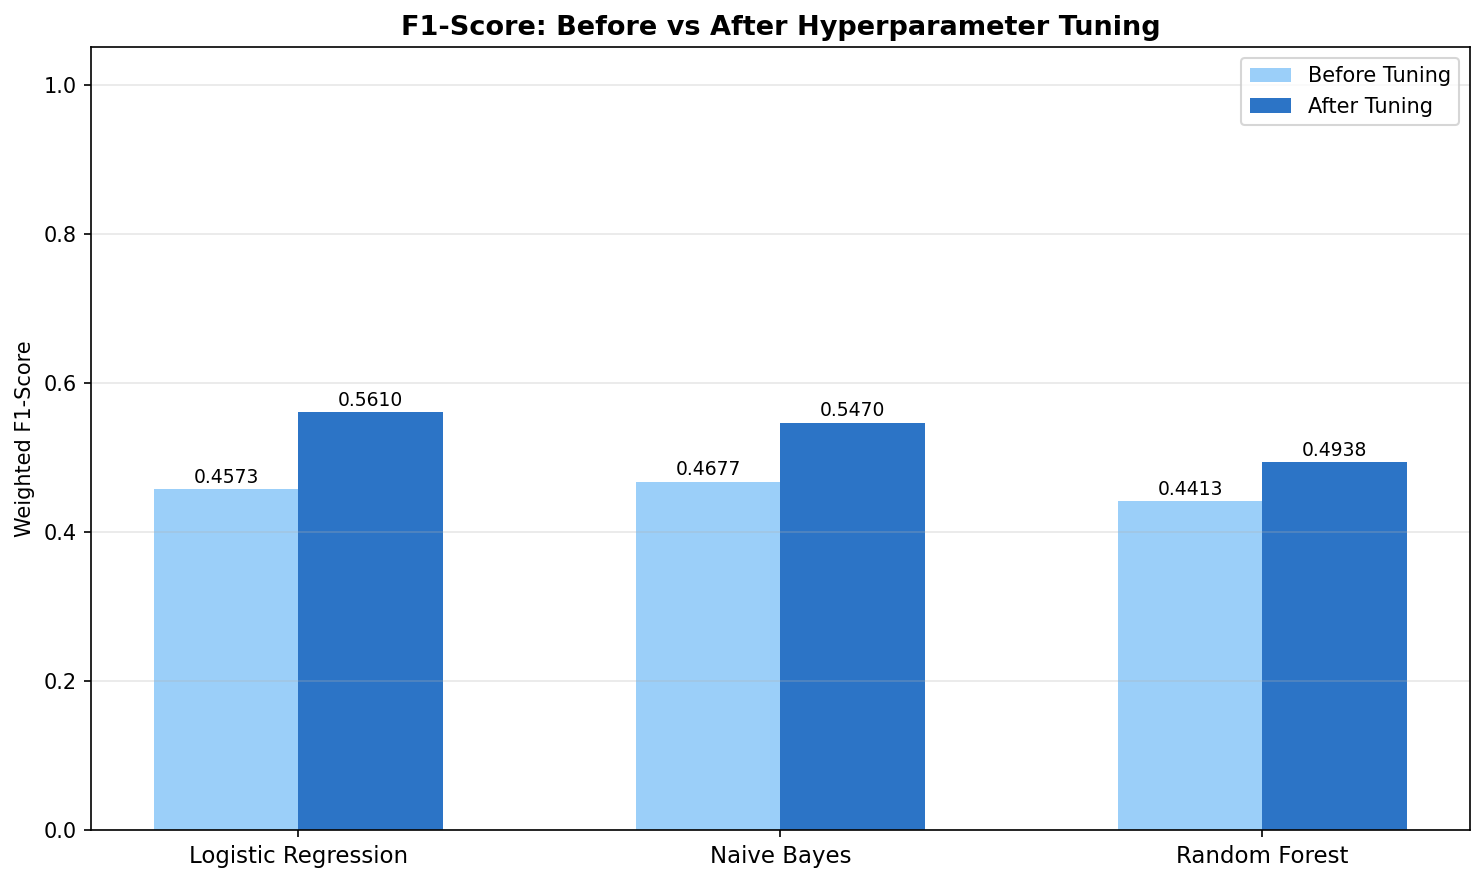

In [28]:
plot_tuning_improvement(before_results, after_results)
Image(str(PLOTS_DIR / "tuning_improvement.png"))

2026-04-21 00:21:41 | INFO | src.models.evaluator |   Saved ROC curves → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\roc_curves.png


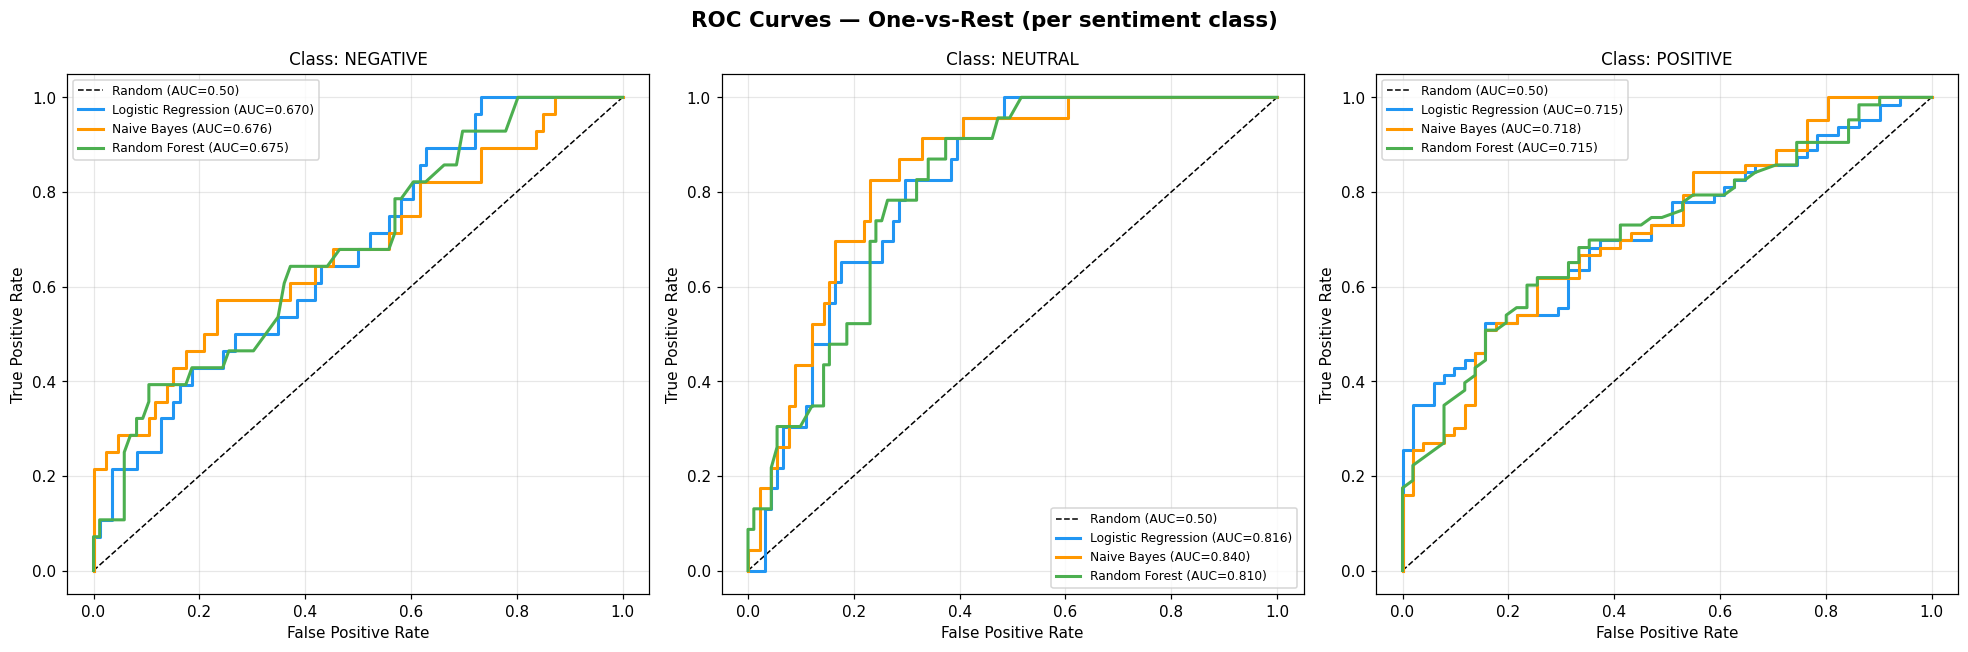

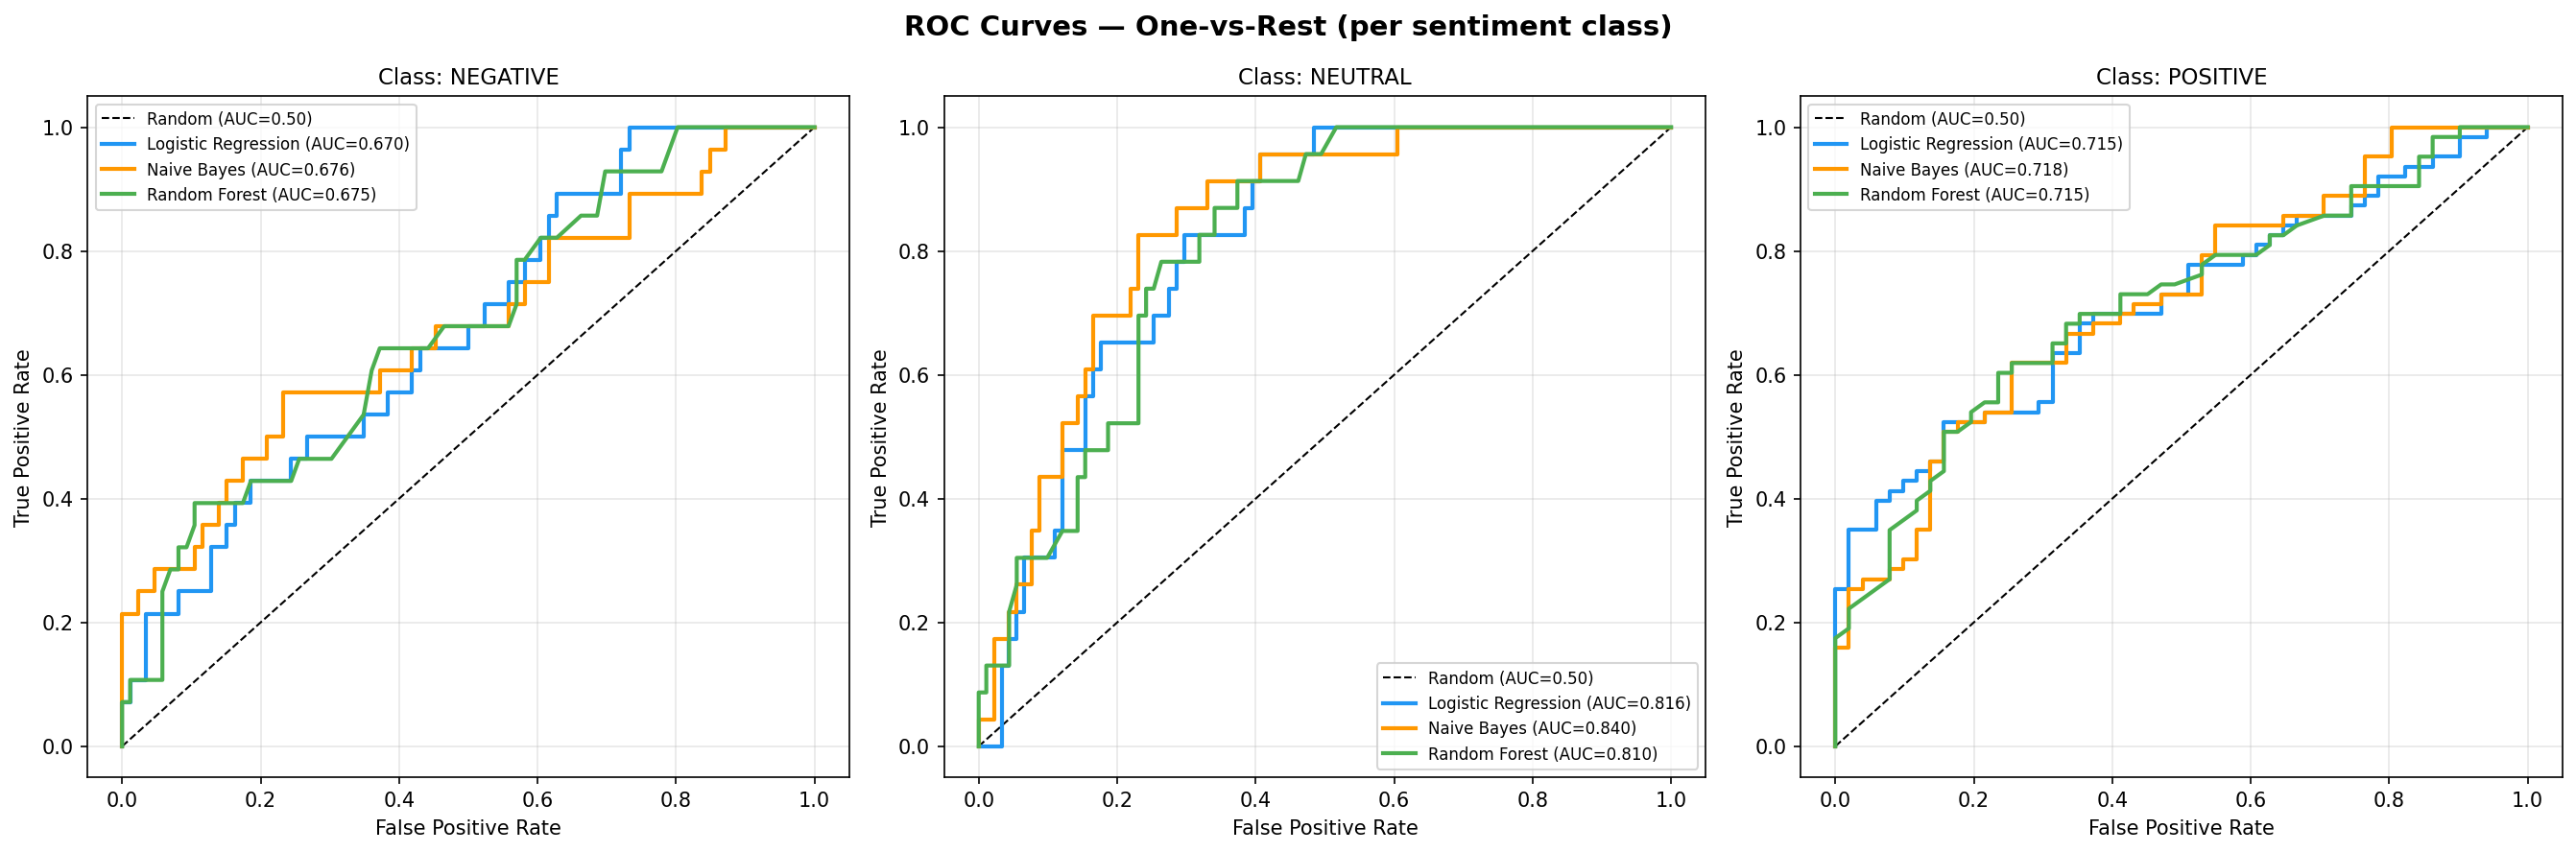

In [29]:
plot_roc_curves(after_results, X_test, y_test)
Image(str(PLOTS_DIR / "roc_curves.png"))

In [30]:
best_key, best_model = select_best_model(after_results)
joblib.dump(best_model,    MODELS_DIR / "best_model.pkl")
joblib.dump(comparison_df, MODELS_DIR / "final_comparison.pkl")
joblib.dump(tuning_df,     MODELS_DIR / "tuning_comparison.pkl")
print(f"\n🏆 Final production model: {best_key.replace('_',' ').title()} — saved to best_model.pkl")

2026-04-21 00:21:49 | INFO | src.models.evaluator | 🏆 Selected best model: Logistic Regression (F1=0.561)

🏆 Final production model: Logistic Regression — saved to best_model.pkl


---
## 🎨 Phase 7 — Visualisations & Stats Report
All 10 plots generated inline + stats JSON saved for the API.

In [32]:
from src.data.data_loader import load_processed_data
from src.visualization.visualizer import (
    plot_sentiment_distribution,
    plot_sentiment_by_subreddit,
    plot_wordclouds,
    plot_sentiment_over_time,
    plot_engagement_analysis,
    plot_text_length_distribution,
    plot_top_ngrams,
    plot_hourly_heatmap,
    plot_radar_chart,
    plot_descriptive_dashboard,
)
from src.visualization.stats_reporter import save_stats_report

df = load_processed_data()
print(f"Loaded {len(df):,} rows for visualisation")

2026-04-21 00:24:29 | INFO | src.data.data_loader | Loaded processed data: 566 rows, 19 cols
Loaded 566 rows for visualisation


Plot 1/10 — Sentiment Distribution
2026-04-21 00:24:40 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\sentiment_distribution.png


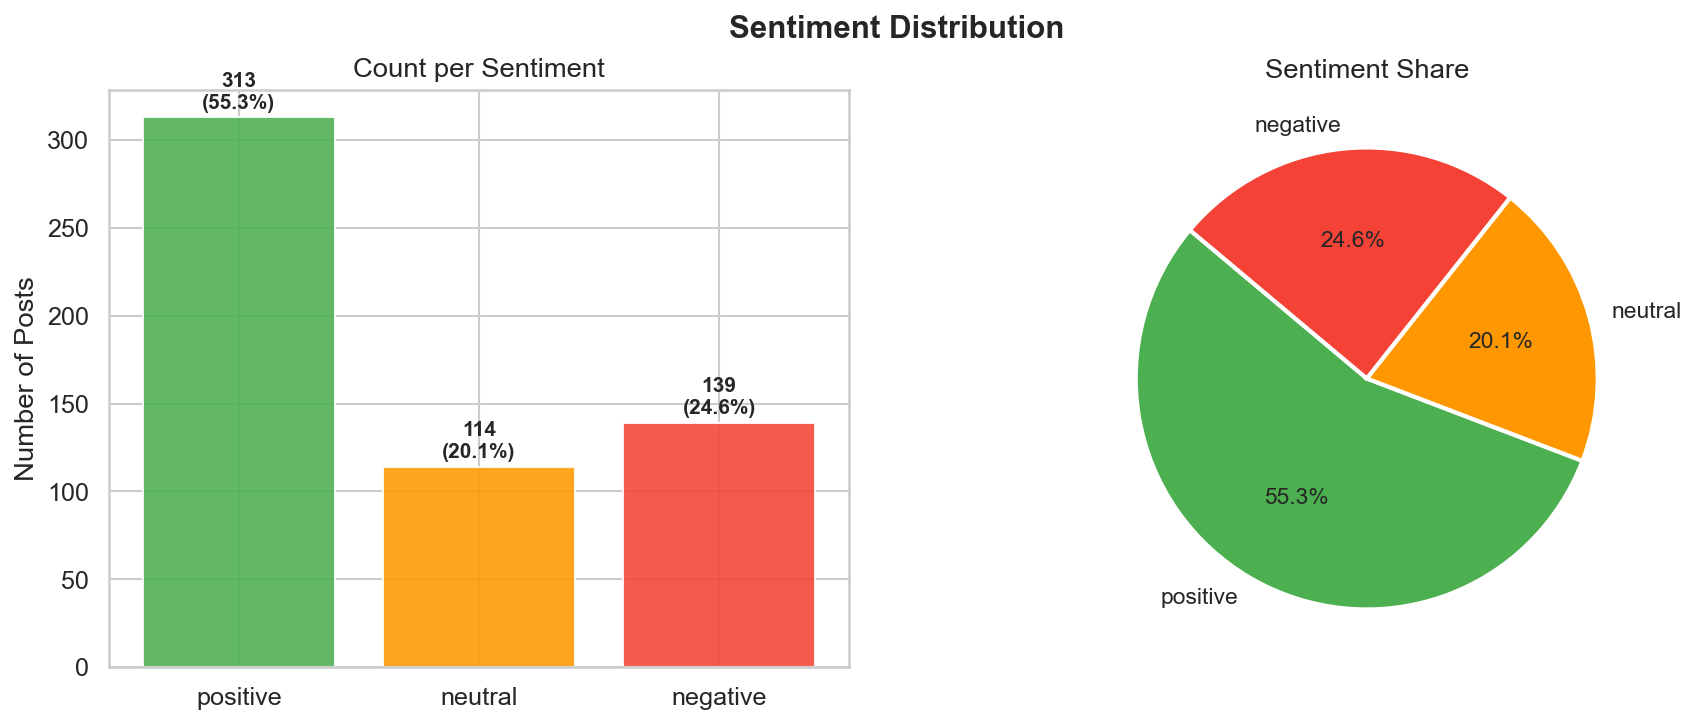

In [33]:
print("Plot 1/10 — Sentiment Distribution")
plot_sentiment_distribution(df)
Image(str(PLOTS_DIR / "sentiment_distribution.png"))

Plot 2/10 — Sentiment by Subreddit
2026-04-21 00:24:53 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\sentiment_by_subreddit.png


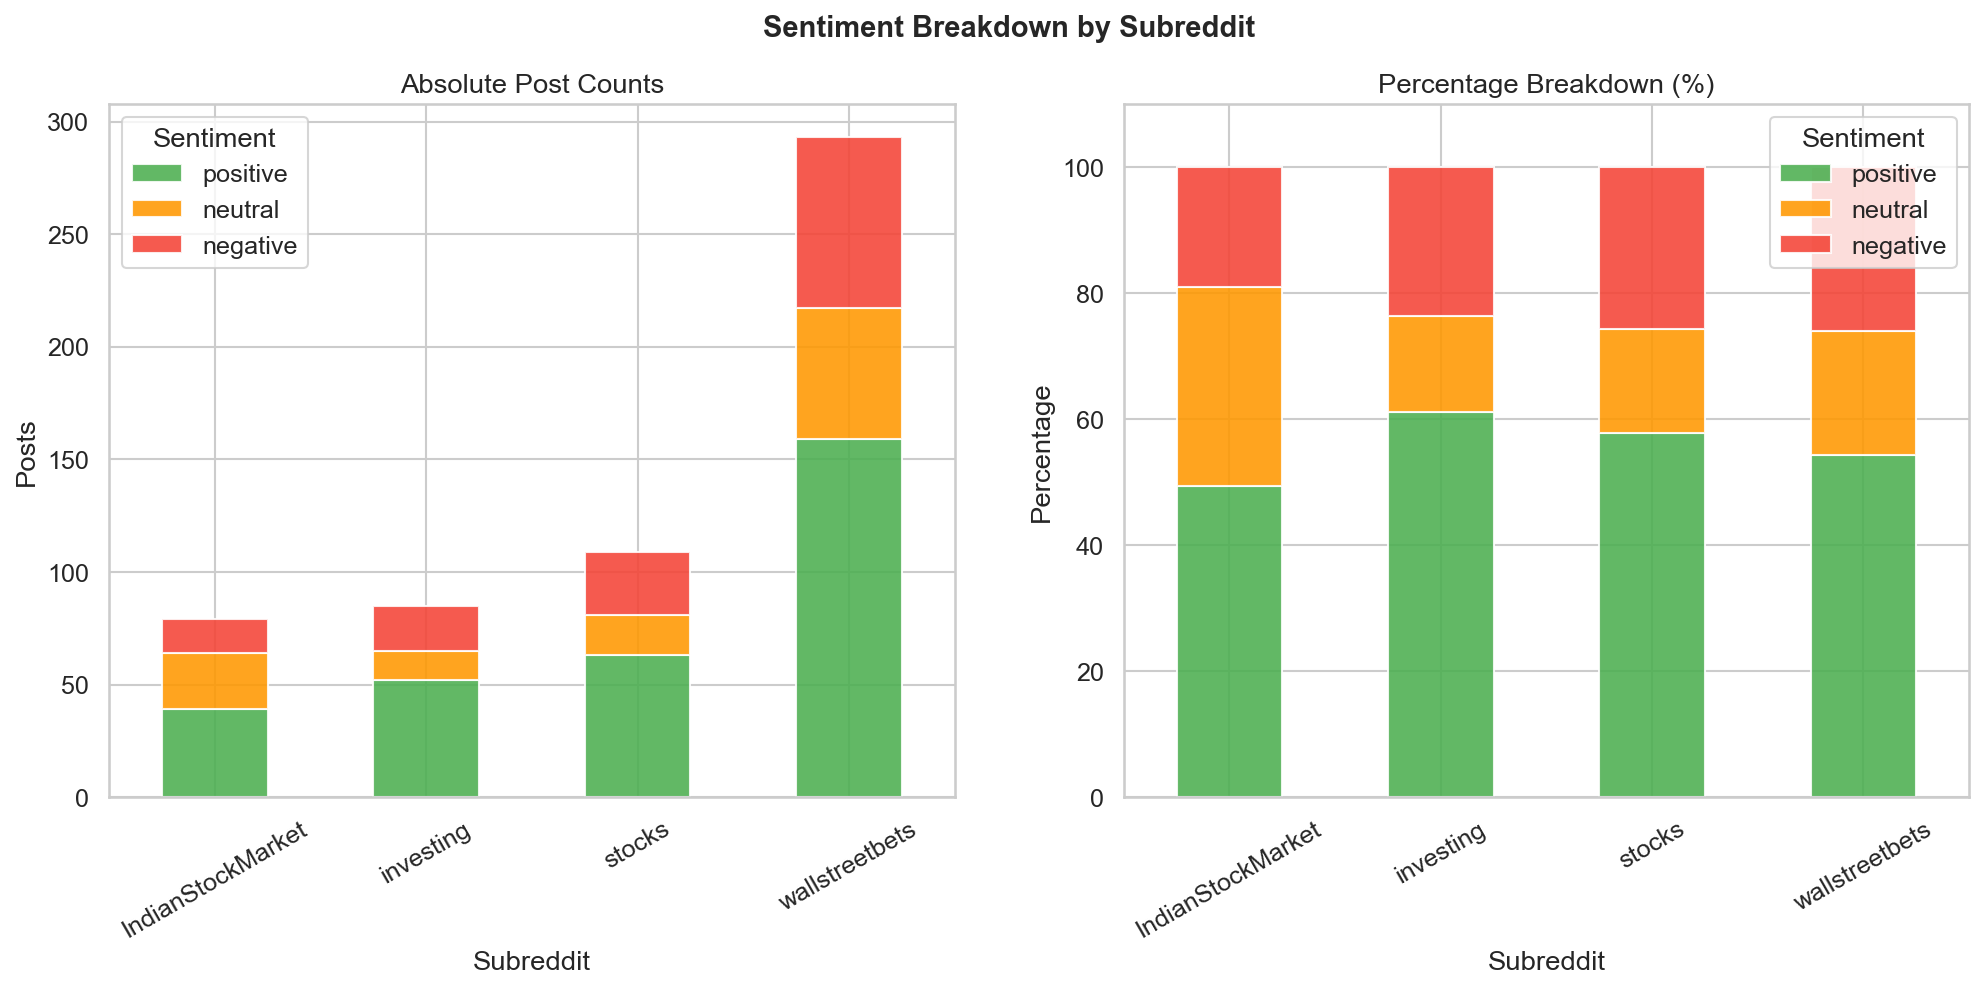

In [34]:
print("Plot 2/10 — Sentiment by Subreddit")
plot_sentiment_by_subreddit(df)
Image(str(PLOTS_DIR / "sentiment_by_subreddit.png"))

Plot 3/10 — Word Clouds
2026-04-21 00:25:14 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\wordclouds.png


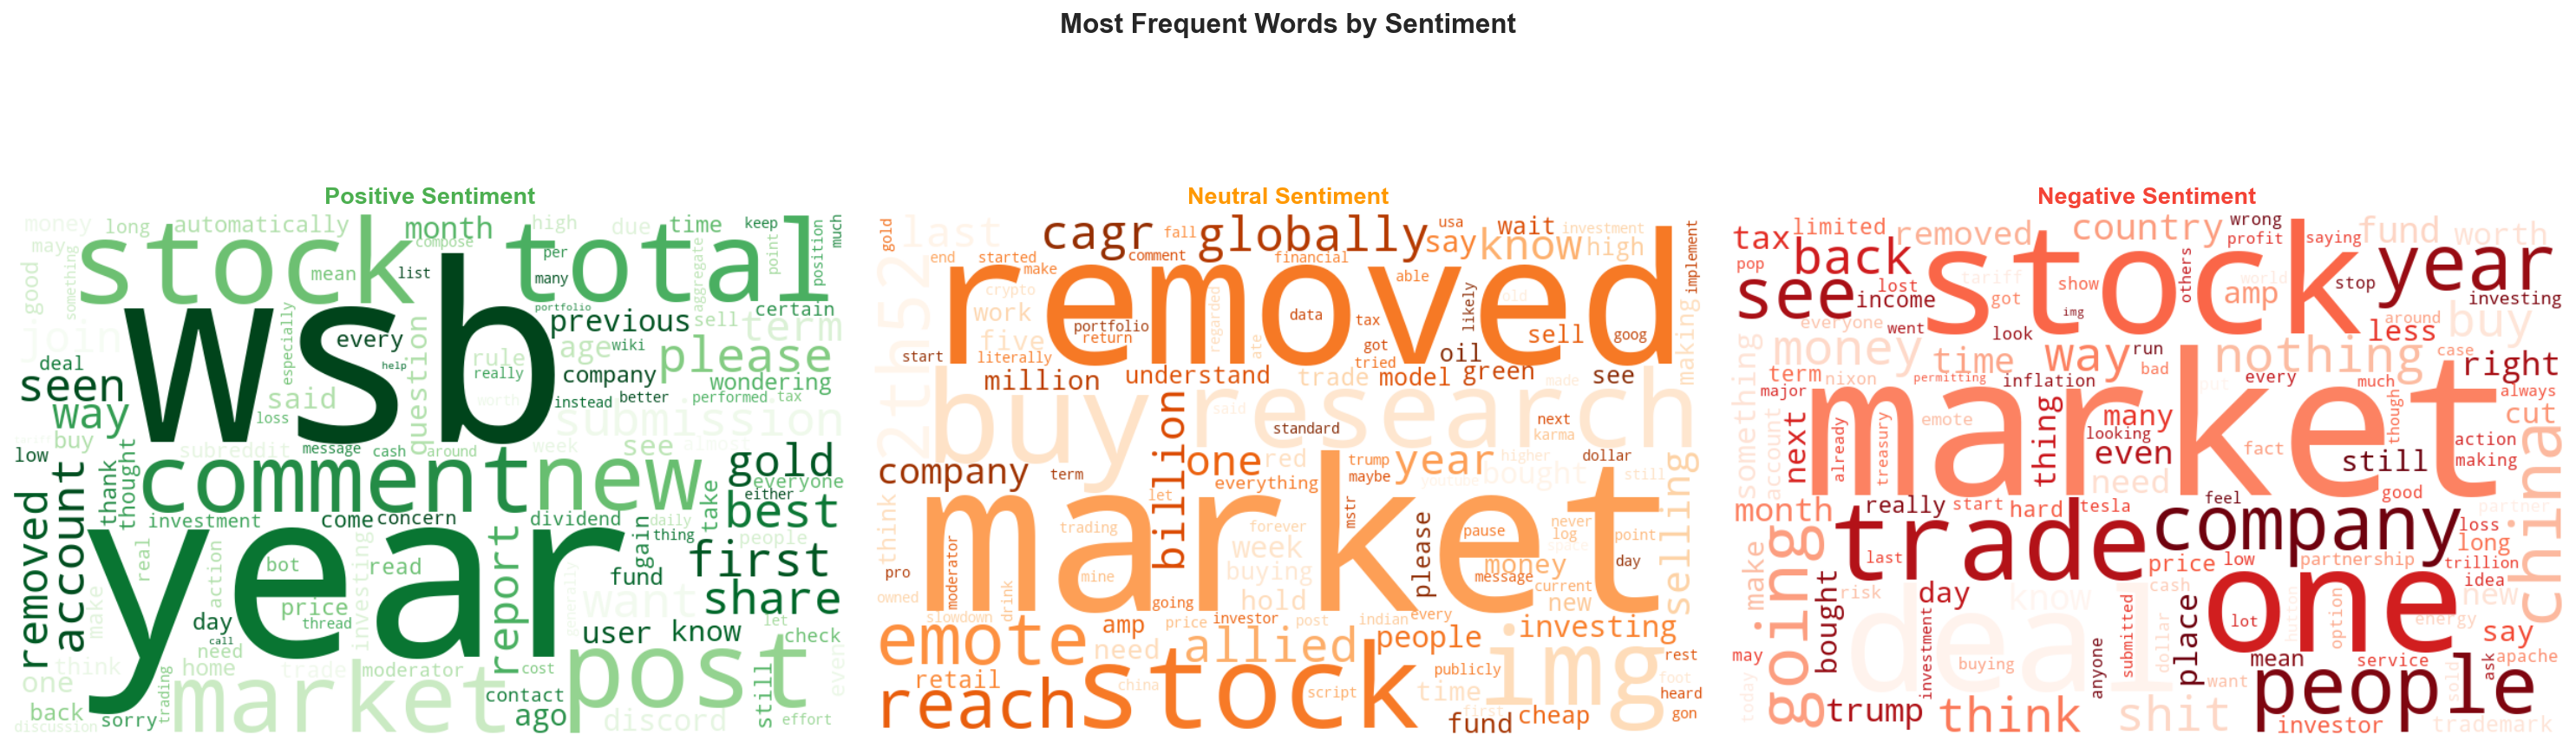

In [35]:
print("Plot 3/10 — Word Clouds")
plot_wordclouds(df)
Image(str(PLOTS_DIR / "wordclouds.png"))

Plot 4/10 — Sentiment Over Time
2026-04-21 00:25:30 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\sentiment_over_time.png


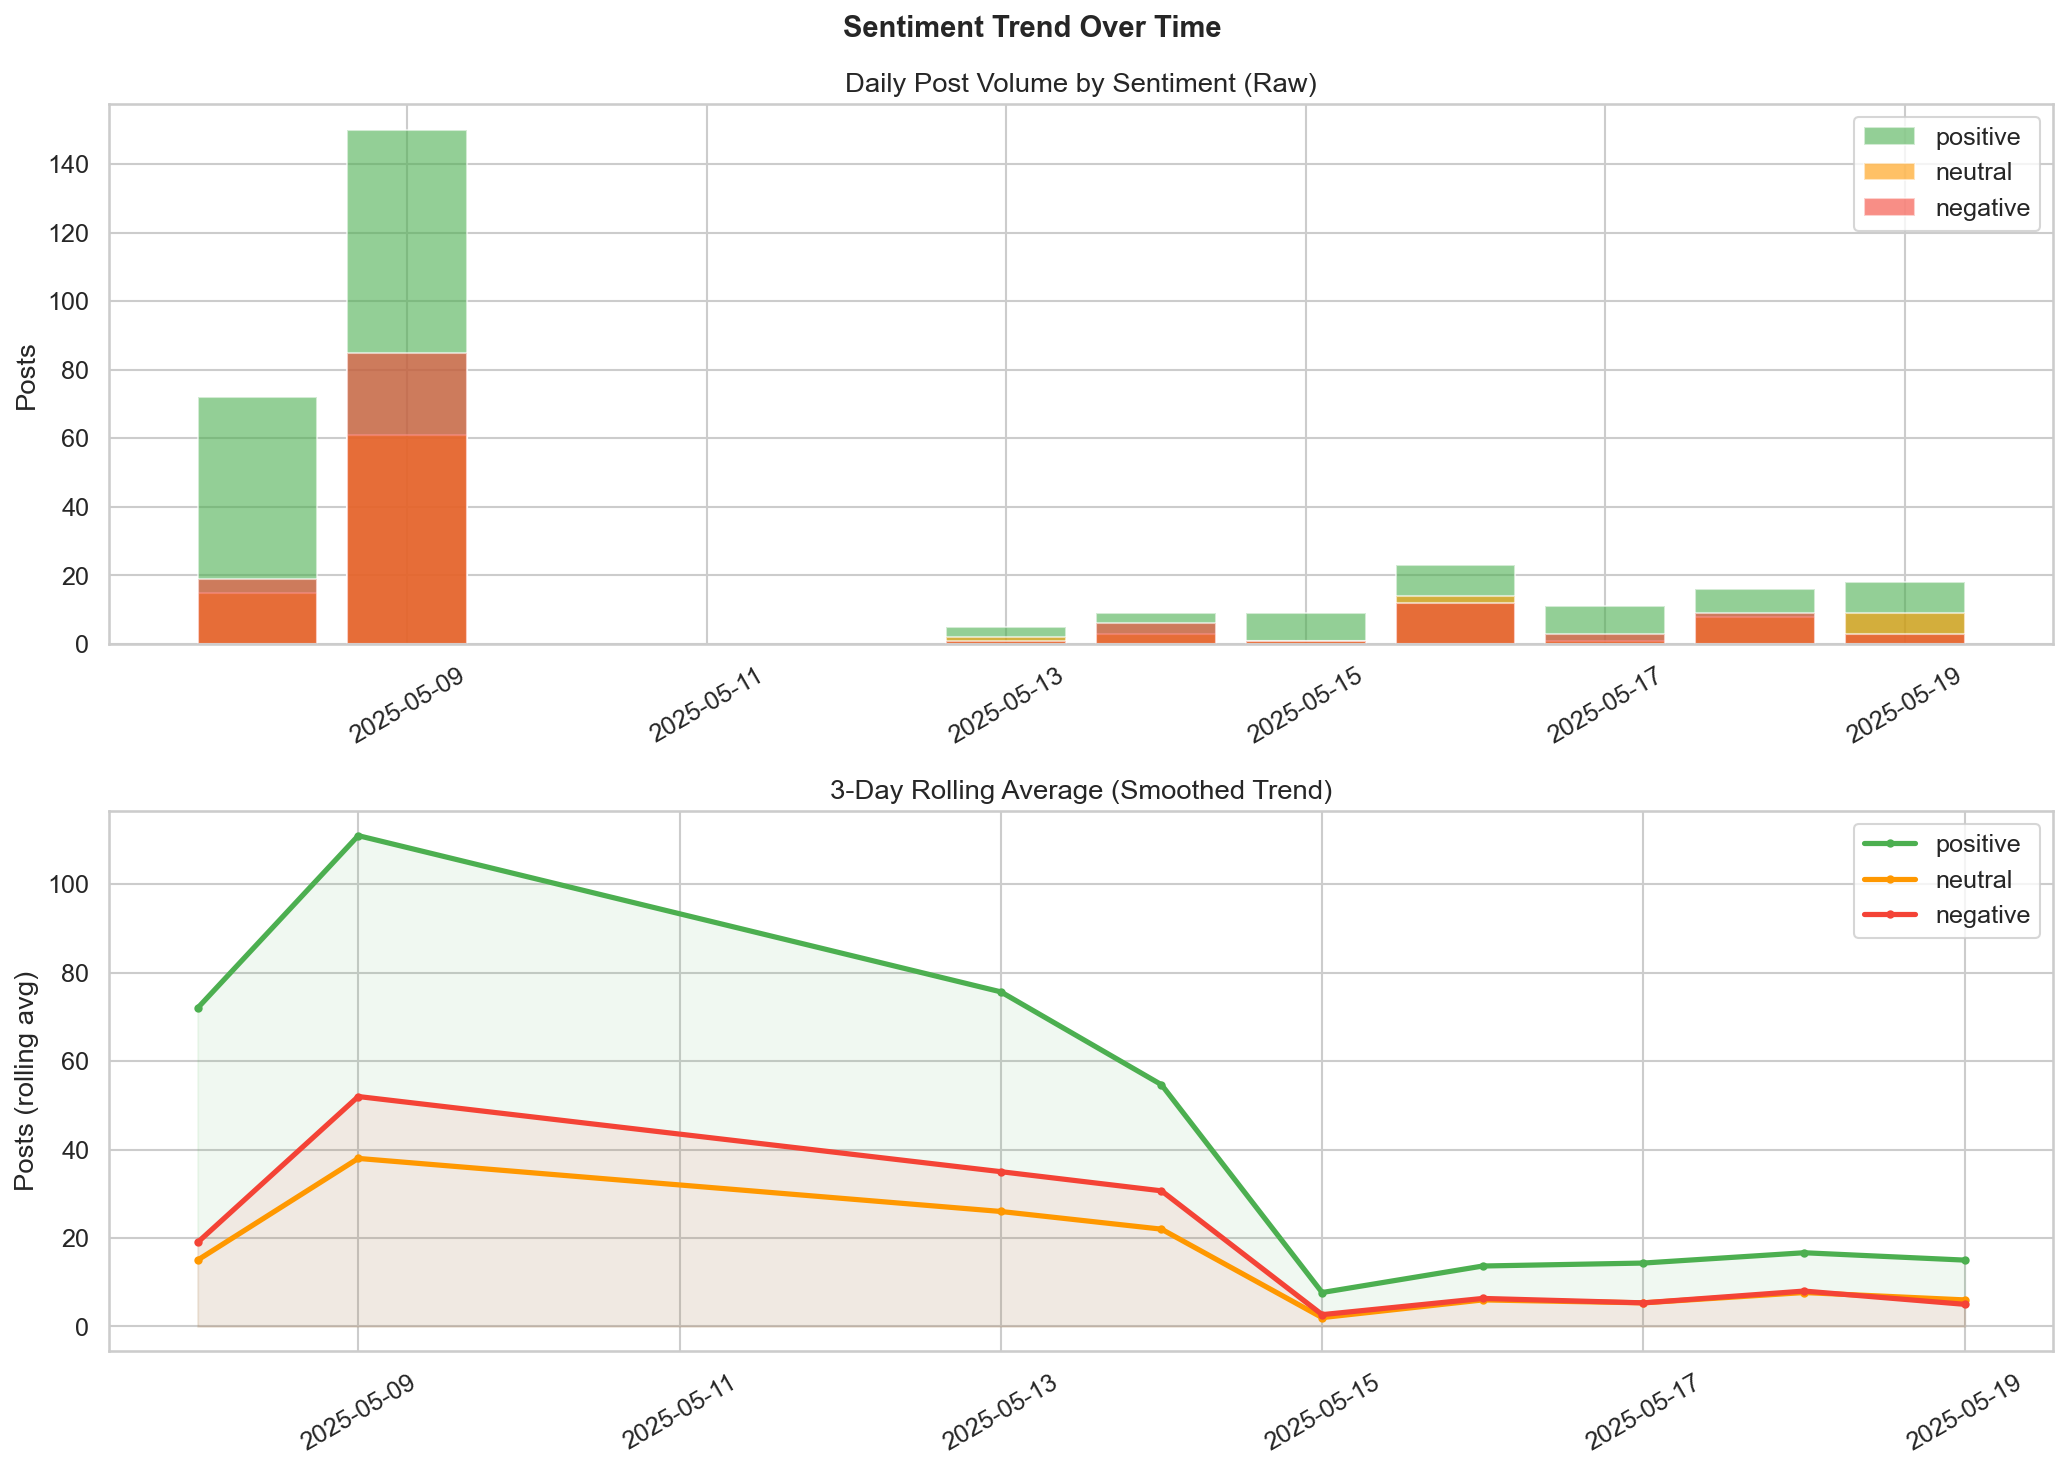

In [36]:
print("Plot 4/10 — Sentiment Over Time")
plot_sentiment_over_time(df)
Image(str(PLOTS_DIR / "sentiment_over_time.png"))

Plot 6/10 — Text Length Distribution
2026-04-21 00:26:19 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\text_length_distribution.png


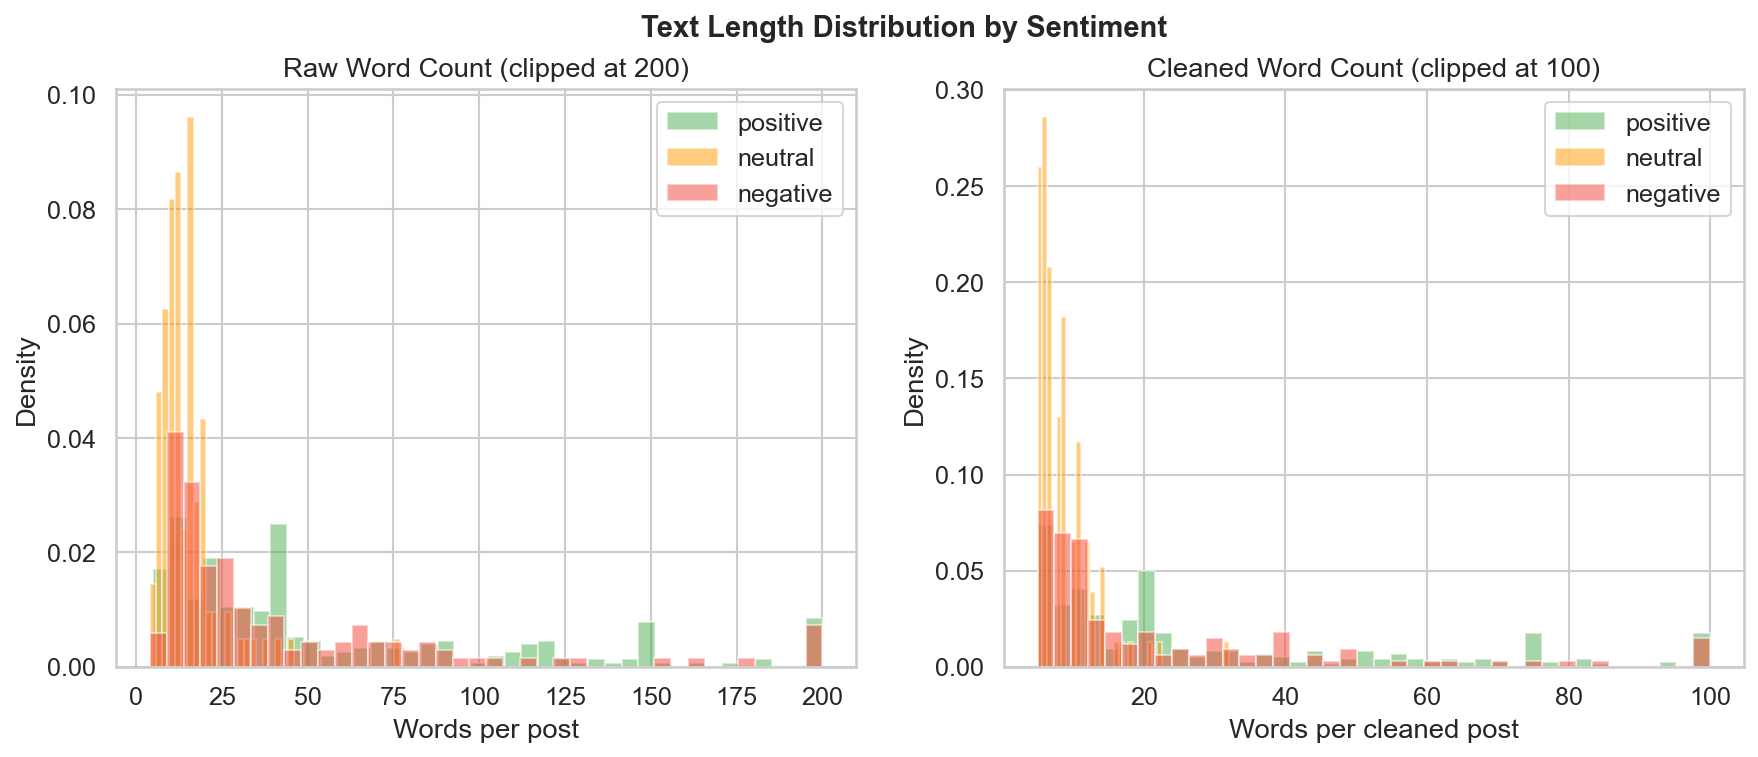

In [38]:
print("Plot 6/10 — Text Length Distribution")
plot_text_length_distribution(df)
Image(str(PLOTS_DIR / "text_length_distribution.png"))

Plot 7/10 — Top Unigrams
2026-04-21 00:26:35 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\top_unigrams.png


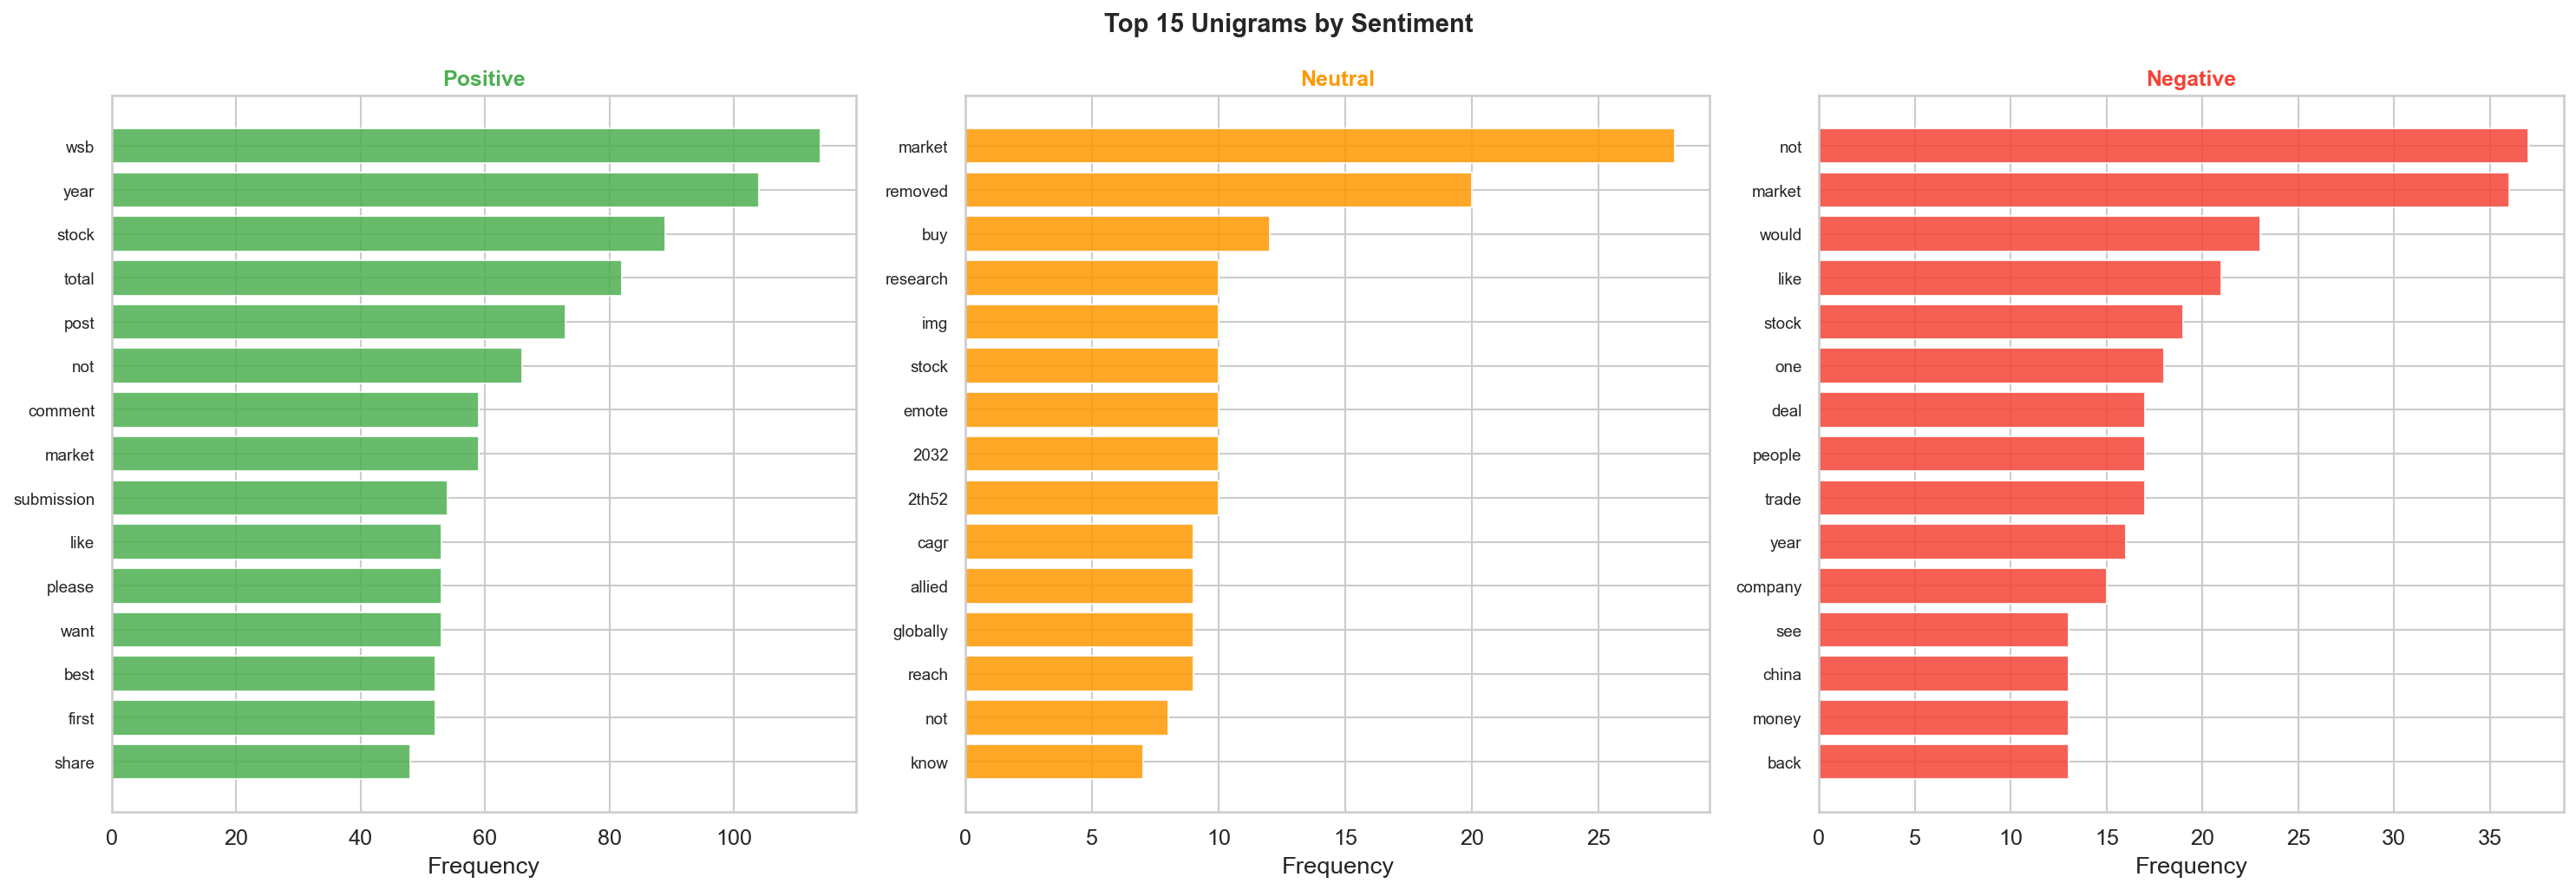

In [39]:
print("Plot 7/10 — Top Unigrams")
plot_top_ngrams(df, n=1, top_k=15)
Image(str(PLOTS_DIR / "top_unigrams.png"))

Plot 8/10 — Top Bigrams
2026-04-21 00:26:49 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\top_bigrams.png


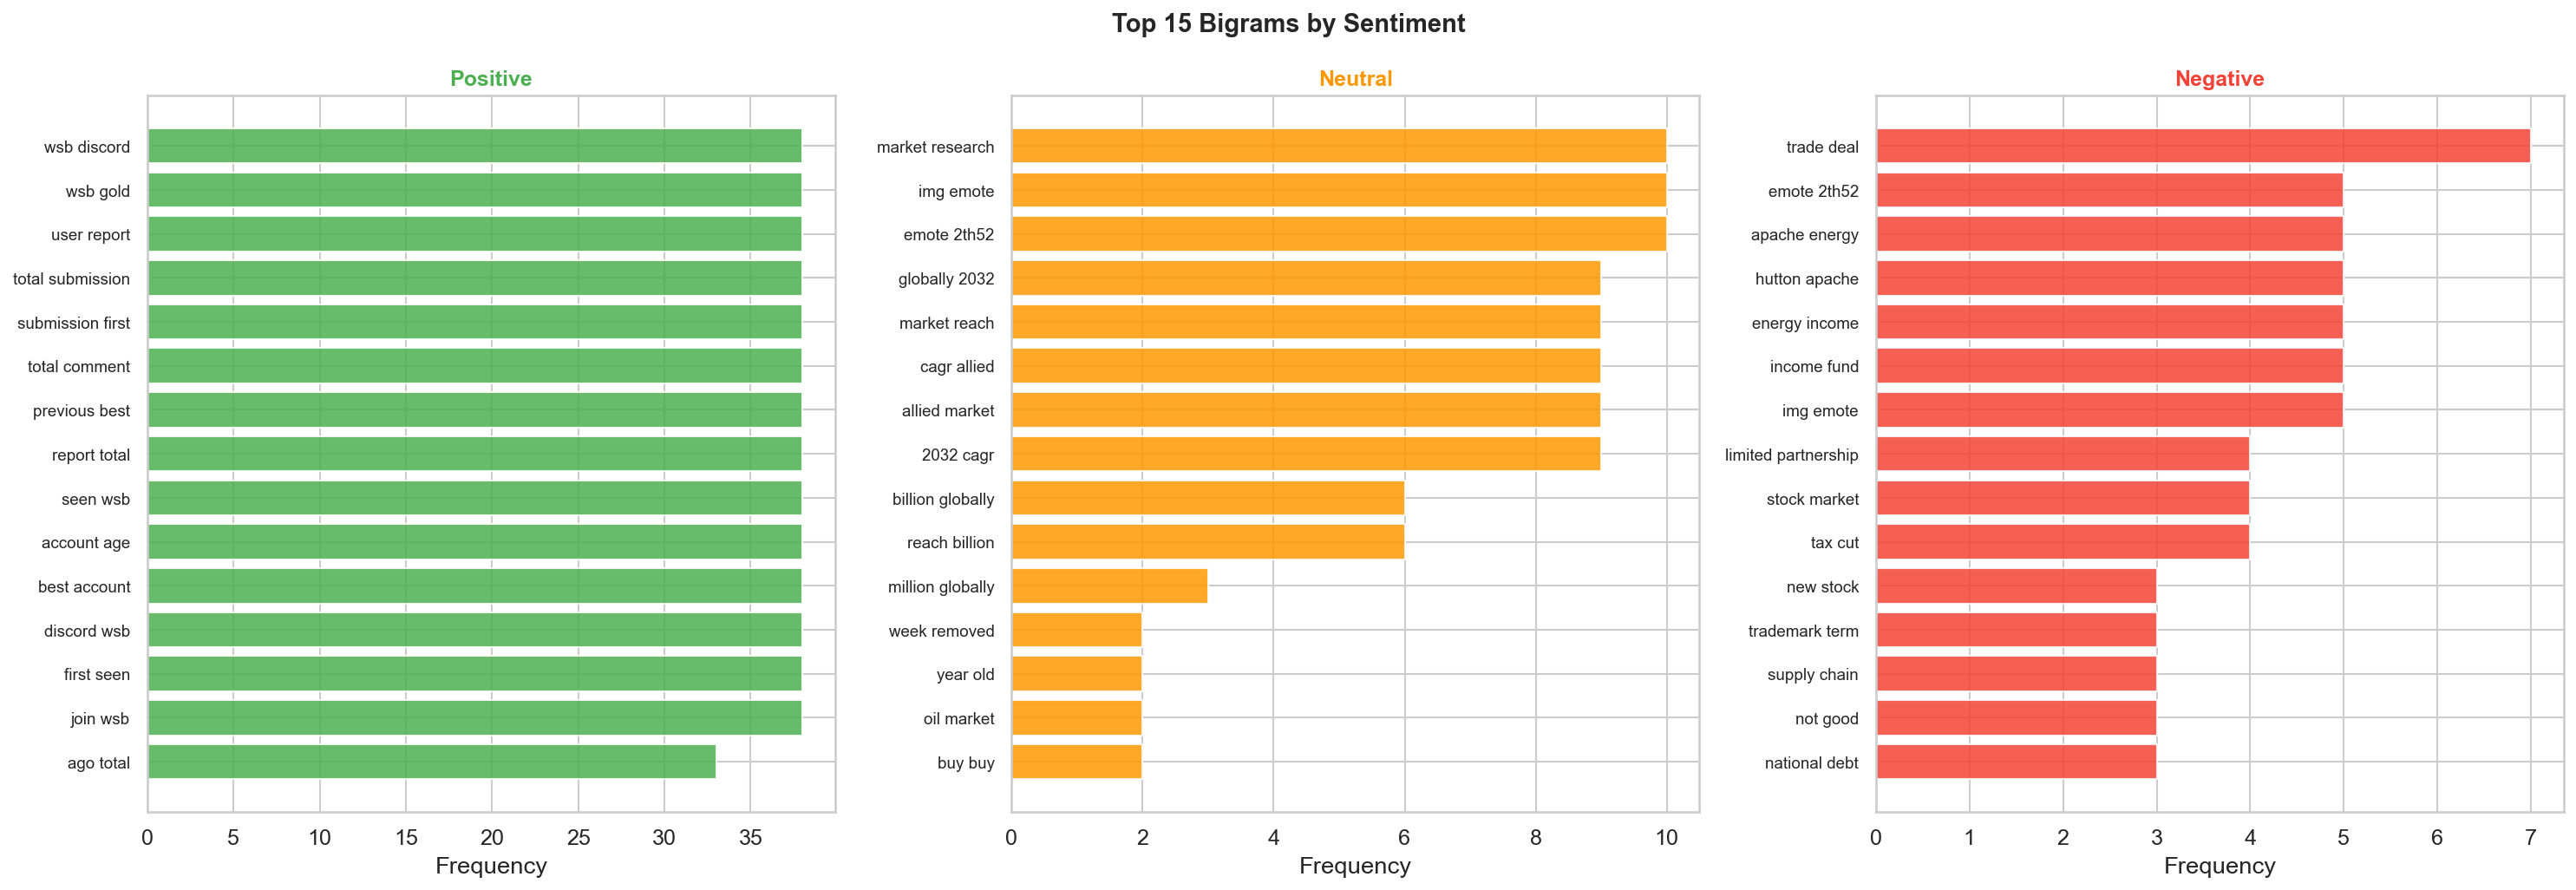

In [40]:
print("Plot 8/10 — Top Bigrams")
plot_top_ngrams(df, n=2, top_k=15)
Image(str(PLOTS_DIR / "top_bigrams.png"))

Plot 9/10 — Hourly Heatmap
2026-04-21 00:26:59 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\hourly_heatmap.png


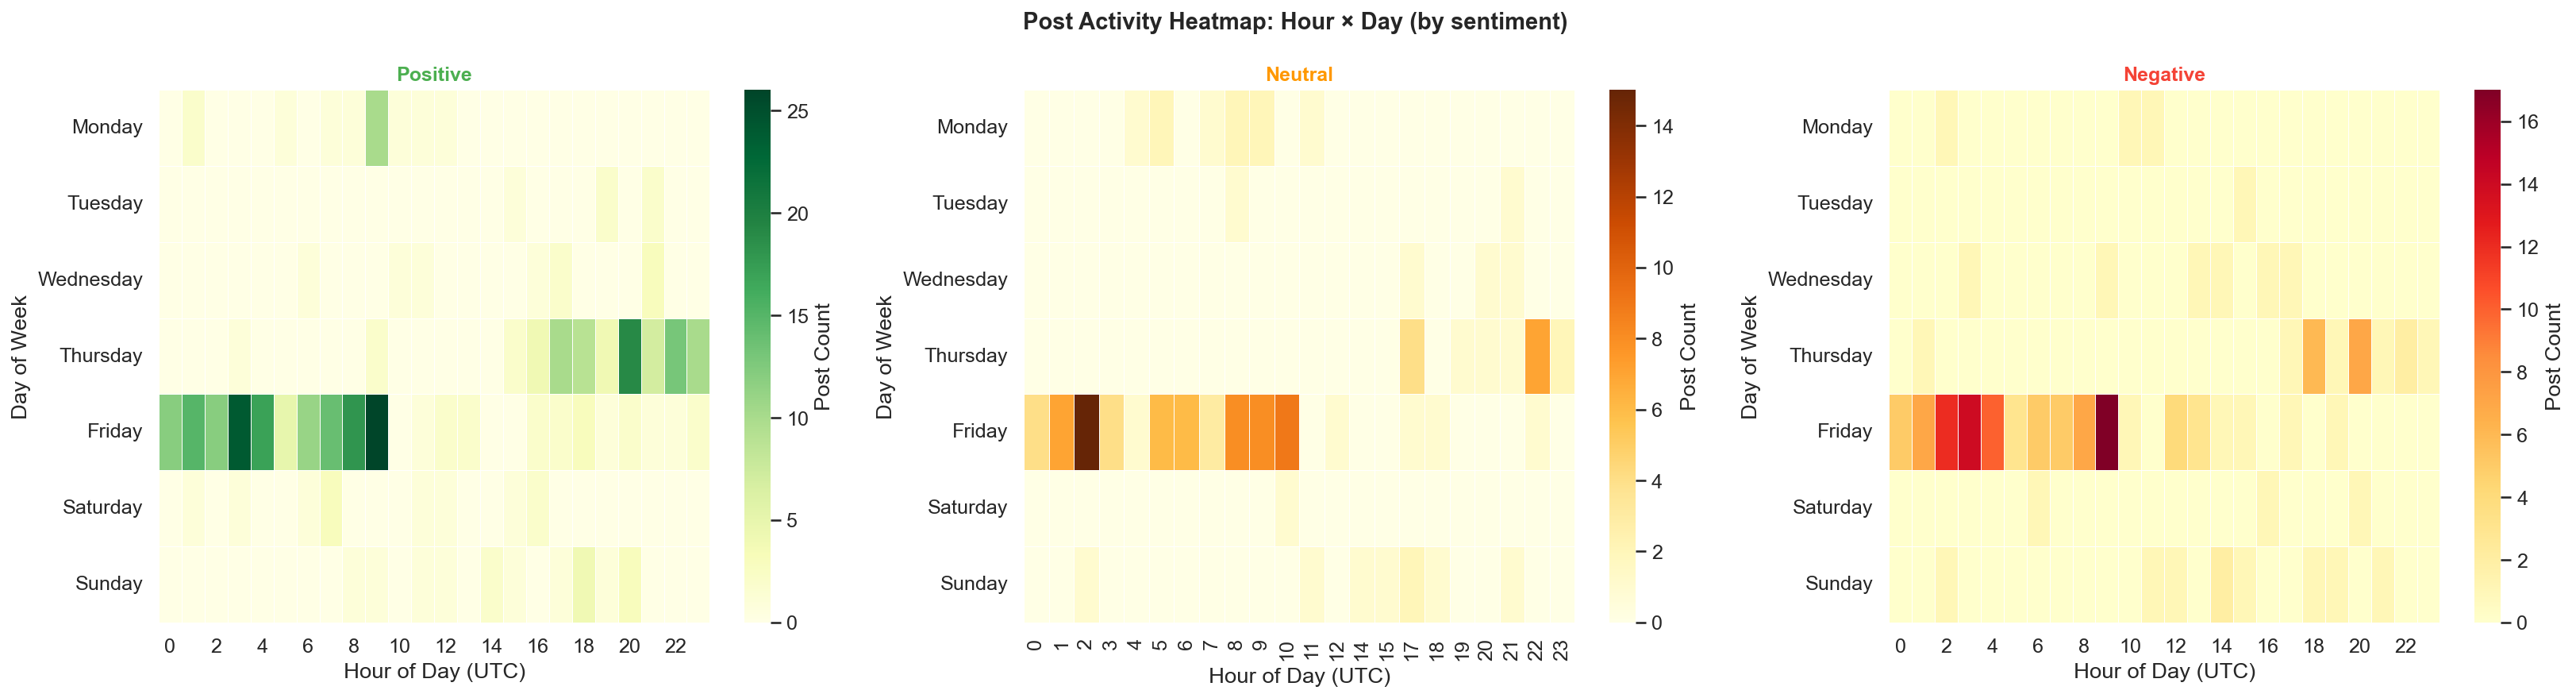

In [41]:
print("Plot 9/10 — Hourly Heatmap")
plot_hourly_heatmap(df)
Image(str(PLOTS_DIR / "hourly_heatmap.png"))

In [42]:
print("Plot 10/10 — Radar Chart")
try:
    comparison_df = joblib.load(MODELS_DIR / "final_comparison.pkl")
    plot_radar_chart(comparison_df)
    Image(str(PLOTS_DIR / "radar_chart.png"))
except FileNotFoundError:
    print("  Skipped — run Phase 6 first to generate final_comparison.pkl")

Plot 10/10 — Radar Chart
2026-04-21 00:27:10 | INFO | src.visualization.visualizer |   ✅ Saved → C:\A-Projects gng\sentiment analysis\finance-sentiment-intelligence\data\plots\radar_chart.png


In [46]:
def save_stats_report(df, plots_dir="reports/plots", output_path="reports/stats_report.txt"):
    import os

    os.makedirs("reports", exist_ok=True)
    os.makedirs(plots_dir, exist_ok=True)

    # 📊 Core stats
    total_posts = len(df)

    sentiment_distribution = (
        df["sentiment"].value_counts(normalize=True).round(3).to_dict()
        if "sentiment" in df.columns else {}
    )

    # 📁 Available plots
    available_plots = [
        f for f in os.listdir(plots_dir)
        if f.endswith(".png")
    ]

    # 📝 Save to file
    with open(output_path, "w") as f:
        f.write("=== DATASET STATS REPORT ===\n\n")
        f.write(f"Total Posts: {total_posts}\n\n")
        f.write(f"Sentiment Distribution:\n{sentiment_distribution}\n\n")
        f.write("Available Plots:\n")
        for p in available_plots:
            f.write(f" - {p}\n")

    print(f"✅ Stats report saved at {output_path}")

    # 🔥 IMPORTANT: return structured data
    return {
        "total_posts": total_posts,
        "sentiment_distribution": sentiment_distribution,
        "available_plots": available_plots
    }

---
## 🔮 Live Prediction Demo
Test the trained model directly here — no API needed.

In [45]:
from src.preprocessing.cleaner import full_clean
import scipy.sparse as sp

vectorizer   = joblib.load(MODELS_DIR / "tfidf_vectorizer.pkl")
best_model   = joblib.load(MODELS_DIR / "best_model.pkl")
feature_names = joblib.load(MODELS_DIR / "feature_names.pkl") if (MODELS_DIR / "feature_names.pkl").exists() else []

label_map = {0: "🔴 Negative", 1: "🟡 Neutral", 2: "🟢 Positive"}

def predict(text: str) -> dict:
    cleaned  = full_clean(text)
    X        = vectorizer.transform([cleaned])
    if feature_names:
        zeros = sp.csr_matrix(np.zeros((1, len(feature_names))))
        X     = sp.hstack([X, zeros])
    pred     = best_model.predict(X)[0]
    proba    = best_model.predict_proba(X)[0]
    return {
        "sentiment"  : label_map[pred],
        "confidence" : f"{proba[pred]*100:.1f}%",
        "positive"   : f"{proba[2]*100:.1f}%",
        "neutral"    : f"{proba[1]*100:.1f}%",
        "negative"   : f"{proba[0]*100:.1f}%",
        "cleaned"    : cleaned,
    }

test_sentences = [
    "Reliance Industries reported record profits this quarter, stock surged 8%",
    "The market is crashing, sell everything before it's too late",
    "HDFC Bank released its Q3 results today",
    "Nifty50 hits all-time high as FIIs pump money into blue-chips",
    "Horrible earnings report, company missed estimates by a mile",
]

print("\n── Live Sentiment Predictions ──\n")
results_list = []
for sentence in test_sentences:
    r = predict(sentence)
    results_list.append({"Text": sentence[:70] + "...", **r})
    print(f"Text      : {sentence}")
    print(f"Sentiment : {r['sentiment']}  (confidence: {r['confidence']})")
    print(f"Scores    : +{r['positive']}  ~{r['neutral']}  -{r['negative']}")
    print()

display(pd.DataFrame(results_list)[["Text", "sentiment", "confidence", "positive", "neutral", "negative"]])


── Live Sentiment Predictions ──

Text      : Reliance Industries reported record profits this quarter, stock surged 8%
Sentiment : 🟢 Positive  (confidence: 77.1%)
Scores    : +77.1%  ~10.1%  -12.8%

Text      : The market is crashing, sell everything before it's too late
Sentiment : 🟡 Neutral  (confidence: 96.8%)
Scores    : +2.8%  ~96.8%  -0.3%

Text      : HDFC Bank released its Q3 results today
Sentiment : 🟢 Positive  (confidence: 84.4%)
Scores    : +84.4%  ~10.3%  -5.3%

Text      : Nifty50 hits all-time high as FIIs pump money into blue-chips
Sentiment : 🟢 Positive  (confidence: 84.8%)
Scores    : +84.8%  ~10.8%  -4.4%

Text      : Horrible earnings report, company missed estimates by a mile
Sentiment : 🟡 Neutral  (confidence: 66.5%)
Scores    : +11.1%  ~66.5%  -22.4%



,Text,sentiment,confidence,positive,neutral,negative
0,Reliance Industries reported record profits th...,🟢 Positive,77.1%,77.1%,10.1%,12.8%
1,"The market is crashing, sell everything before...",🟡 Neutral,96.8%,2.8%,96.8%,0.3%
2,HDFC Bank released its Q3 results today...,🟢 Positive,84.4%,84.4%,10.3%,5.3%
3,Nifty50 hits all-time high as FIIs pump money ...,🟢 Positive,84.8%,84.8%,10.8%,4.4%
4,"Horrible earnings report, company missed estim...",🟡 Neutral,66.5%,11.1%,66.5%,22.4%


---
## ✅ All Done!

Everything is saved in `data/`:
```
data/
├── raw/reddit_posts.csv
├── processed/processed_posts.csv
├── processed/stats_report.json
├── models/best_model.pkl
├── models/tfidf_vectorizer.pkl
└── plots/*.png  (11 plots)
```

To start the API, open a terminal and run:
```bash
uvicorn backend.main:app --reload --port 8000
```
Then visit → http://localhost:8000/docs